EAE3709 APLICACIONES DE  MACHINE LEARNING EN ECONOMÍA <br>
1ER SEMESTRE 2025 <br>
INSTITUTO DE ECONOMÍA <br>
PONTIFICIA UNIVERSIDAD CATÓLICA DE CHILE


# **TAREA 2**


---


Profesor:
- Joaquín Pérez Lapillo

Ayudantes:

- Luis García B.
- Sebastián Hernández B.
- Oscar Herrera G.


**Complete sus datos:**

- Nombre y apellido:
  - María Constanza López
  - Franz Celi Ramírez
- Usuario de GitHub (opcional):  https://github.com/fabelo4/AMLE-2025


## Instrucciones

- Descargue el notebook y cárguelo en su Drive.
- Todas las preguntas deben ser contestadas en su notebook.
- Para que una pregunta esté correcta el código debe correr.
- Si es necesario, realice comentarios breves en su código explicando lo que está realizando o sus resultados.
- Una vez culminada su tarea, suba su notebook al buzón de tareas de Canvas.
- La fecha y hora límite de esta tarea es el _**viernes 30 de mayo a las 20:00 hrs**_.



### Distribución de puntaje


| Pregunta                        | Puntaje |
|--------------------------------|---------|
| Pregunta 1.0                   |    1    |
| Pregunta 1.1                   |    2    |
| Pregunta 1.2                   |    2    |
| Pregunta 1.3                   |    2    |
| Pregunta 1.4                   |    5    |
| Pregunta 1.5                   |    5    |
| Pregunta 1.6                   |    2    |
| Pregunta 1.7                   |    2    |
| Pregunta 1.8                   |    3    |
| Pregunta 1.9                   |    3    |
| Pregunta 1.10                   |    5    |
| Pregunta 1.11                   |    5    |
| Pregunta 1.12                   |    5    |
| Pregunta 1.13                   |    3    |
| Pregunta 1.13                   |    5    |
| Pregunta 2.0                   |    1    |
| Pregunta 2.1                   |    1    |
| Pregunta 2.2                   |    1    |
| Pregunta 2.3                   |    3    |
| Pregunta 2.4                   |    5    |
| Pregunta 2.5                   |    3    |
| Pregunta 2.6                   |    3    |
| Pregunta 2.7                   |    3    |
| Pregunta 2.8                   |    5    |
| Pregunta 2.9                   |    7    |
| Pregunta 2.10                   |    4    |
| Pregunta 2.11                   |    3    |
| Pregunta 2.12                   |    1    |
| Pregunta 2.13                   |    2    |
| Pregunta 2.14                   |    3    |
| Pregunta 2.15                   |    2    |
| Pregunta 2.16                   |    3    |

Total: 100 pts.


# 1. Clasificación

En esta pregunta trabajaremos con un _dataset_ que contiene información campañas de marketing de un banco portugués. La campaña se enfocó en llamadas telefónicas a distintos segmentos de clientes, de forma individualizada, con el objetivo incenitvar la toma depósitos por parte de los clientes.

El problema presentado en este ejecicio busca predecir si el cliente suscribirá (sí/no) un depósito a plazo.



A continuación, se despliega información oficial sobre el _dataset_:

| Variable Name | Role    | Type        | Description                                                                                                                               |
|---------------|---------|-------------|-------------------------------------------------------------------------------------------------------------------------------------------|
| age           | Feature | Integer     |     years of age                                                                                                                                      |
| job           | Feature | Categorical | type of job |
| marital       | Feature | Categorical | marital status                          |
| education     | Feature | Categorical | Education level         |
| default       | Feature | Binary      | has credit in default?                                                                                                                    |
| balance       | Feature | Integer     | average yearly balance in euros                                                                                                                    |
| housing       | Feature | Binary      | has housing loan?                                                                                                                         |
| loan          | Feature | Binary      | has personal loan?                                                                                                                        |
| contact       | Feature | Categorical | contact communication type                                                                         |
| day_of_week   | Feature | Date        | last contact day of the month (numeric)                                                                                                              |
| month         | Feature | Date        | last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')                                                          |
| duration*      | Feature | Integer     | last contact duration, in seconds (numeric).  |
| campaign      | Feature | Integer     | number of contacts performed during this campaign and for this client                                      |
| pdays         | Feature | Integer     | number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted) |
| previous      | Feature | Integer     | number of contacts performed before this campaign and for this client                                                                       |
| poutcome      | Feature | Categorical | outcome of the previous marketing campaign                                                |
| y             | Target  | Binary      | has the client subscribed a term deposit?                                                                                                 |


*Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.



En el sitio web [https://archive.ics.uci.edu/dataset/222/bank+marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) podrá encontrar información oficial del _dataset_.

Use el código otorgado a continuación para importar los datos.


In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets


## Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import textwrap
!pip install tabulate
import tabulate as tab
import sklearn

### Pregunta 1.0

Concatene `X` e `y` en un dataframe consolidado.

Muestre las primeras cinco observaciones en el dataframe consolidado. Despliegue información sobre el tipo de variable de cada una de las columnas del dataframe y despliegue estadísticas descriptivas de las variables según su tipo.

In [ ]:
# Concatenar X e y en un DataFrame consolidado
df2= pd.concat([X, y], axis=1)

# Se elimina la variable "duration"
df2 = df2.drop('duration', axis=1)

# Mostrar las primeras cinco observaciones
df2.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,1,-1,0,NaN,no


In [ ]:
# Desplegar información sobre los tipos de variables
print("\nInformación del DataFrame:")
print(df2.info())

# Estadísticas descriptivas de variables numéricas
print("\nEstadísticas descriptivas de variables numéricas:")
print(df2.describe())

# Estadísticas descriptivas de variables categóricas
categorical_vars = df2.select_dtypes(include=['object'])
print("\nEstadísticas descriptivas de variables categóricas:")
print(categorical_vars.describe())

# Frecuencia de valores únicos por columna categórica
for col in categorical_vars.columns:
    print(f"\nFrecuencia de valores en {col}:")
    print(df2[col].value_counts())


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  campaign     45211 non-null  int64 
 12  pdays        45211 non-null  int64 
 13  previous     45211 non-null  int64 
 14  poutcome     8252 non-null   object
 15  y            45211 non-null  object
dtypes: int64(6), object(10)
memory usage: 5.5+ MB
None

Estadísticas descriptivas de variables numéricas:
                ag

### Pregunta 1.1

Identifique las columnas que presentan _missing values_ e indique el número de _missing values_ que poseen.

Impute los valores nulos con el método que estime conveniente, justificando su decisión.

In [ ]:
# Identificar columnas con valores nulos
missing_values = df2.isnull().sum()

# Filtrar solo las columnas con valores faltantes
missing_values = missing_values[missing_values > 0]
print("Cantidad de valores faltantes por columna:\n", missing_values)

# Eliminar columnas solo si están presentes en el DataFrame
cols_to_drop = ['contact', 'poutcome']
existing_cols_to_drop = [col for col in cols_to_drop if col in df2.columns]
df2.drop(columns=existing_cols_to_drop, inplace=True)

#Imputación de datos faltantes-- variables categoricas con la Moda
#y variables num con la mediana
df2['balance'] = df2['balance'].fillna(df2['balance'].median())
df2['job'] = df2['job'].fillna(df2['job'].mode()[0])
df2['education'] = df2['education'].fillna(df2['education'].mode()[0])

Cantidad de valores faltantes por columna:
 job            288
education     1857
contact      13020
poutcome     36959
dtype: int64


In [ ]:
# Verificar que no queden valores nulos
print(df2.isnull().sum())

age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
day_of_week    0
month          0
campaign       0
pdays          0
previous       0
y              0
dtype: int64


Tras un análisis de los datos, se identificaron valores faltantes en las variables 'contact', 'poutcome', 'job' y 'education'. Dado el elevado número de nulos en 'contact' y 'poutcome', y considerando su menor relevancia para la predicción, estas columnas fueron eliminadas. Para 'job' y 'education', variables con un rol que pareciera ser fundamental en el análisis, se procedió a imputar los valores faltantes utilizando la moda. La variable numérica 'balance', también con valores faltantes, fue imputada con la mediana. Este enfoque permite mantener la mayor cantidad de datos relevantes mientras se abordan los missing values de manera adecuada para el modelado.

### Pregunta 1.2


Genere histogramas de las variables categóricas desagregando por la variable objetivo de interés. Interprete las relaciones que observa.

Responda: ¿Cuáles creen que son las variables categóricas más relevantes a la hora de determinar si el individuo hará un depósito?

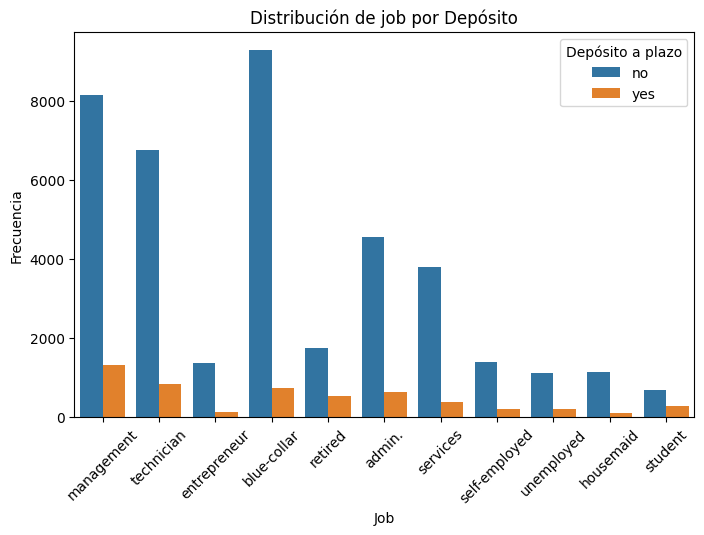

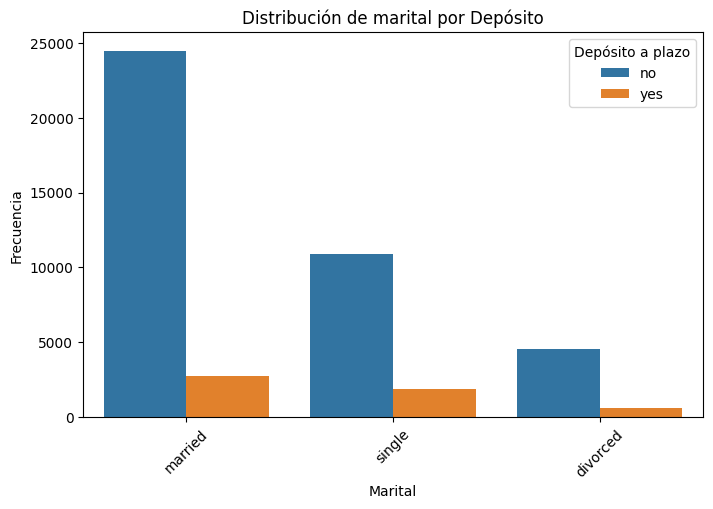

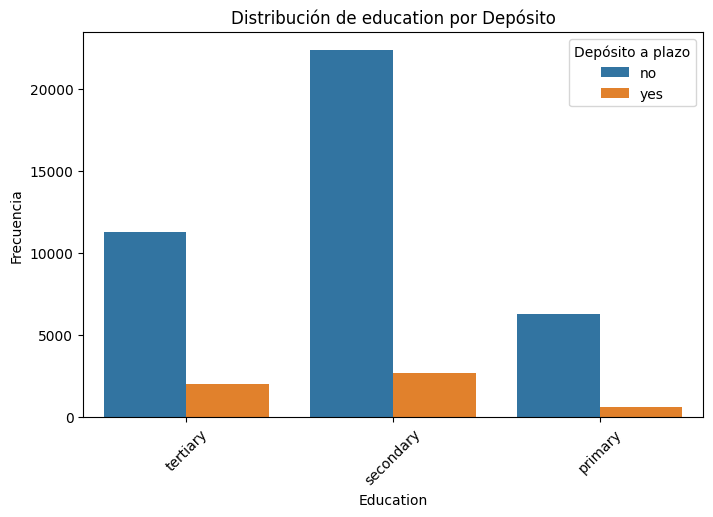

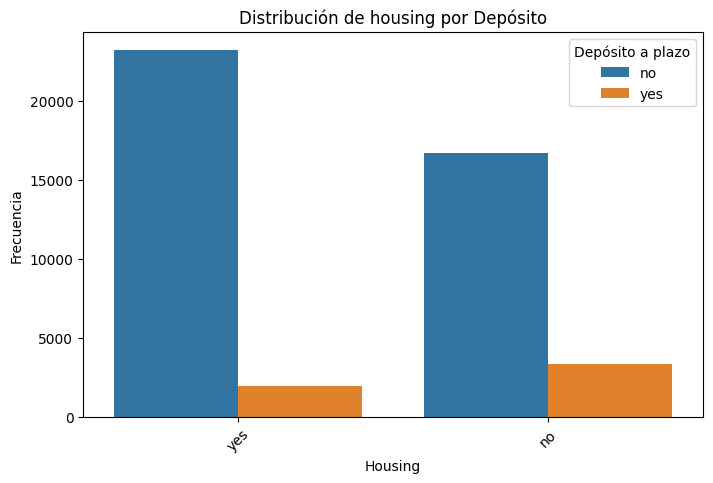

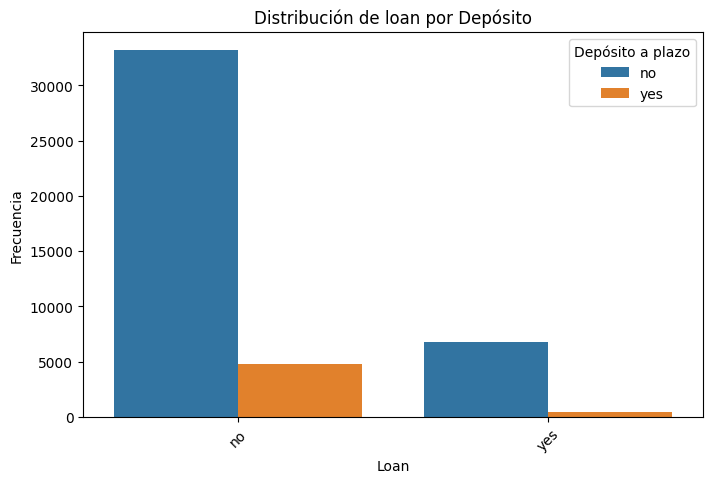

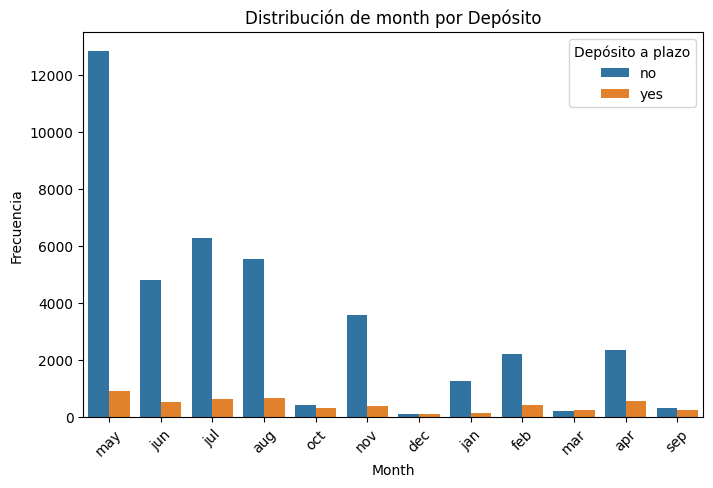

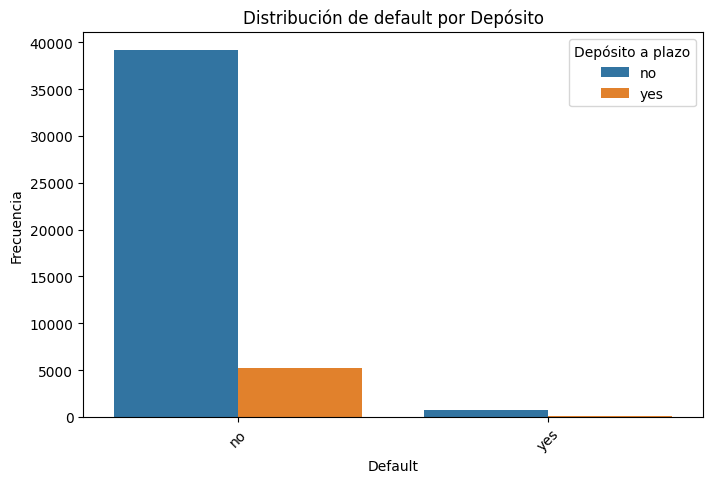

In [ ]:
# Listar variables categóricas a graficar
categorical_vars = ['job', 'marital','education','housing','loan','month','default']

# Generar histogramas desagregados por la variable objetivo
for var in categorical_vars:
    plt.figure(figsize=(8,5))
    sns.countplot(x=var, hue='y', data=df2)
    plt.xticks(rotation=45)
    plt.xlabel(var.replace("_", " ").title())  # Formatear nombre de variable
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución de {var.replace('_', ' ')} por Depósito")
    plt.legend(title="Depósito a plazo")
    plt.show()

A partir del analisis exploratorio de los histogramas presentados. Se observa una variación notable en la proporción de individuos que realizan un depósito en función de su empleo, nivel educativo, el mes de contacto, y la condición de incumplimiento crediticio. Asimismo, la posesión de un préstamo hipotecario o personal también parece influir en la decisión de realizar un depósito. Estas variables sugieren ser relevantes en la modelización predictiva de la aceptación de depósitos a plazo.

### Pregunta 1.3

Identifique _outliers_ entre las variables numéricas del dataset. Además, impute estas observaciones si usted lo considera necesario. Justifique su decisión.

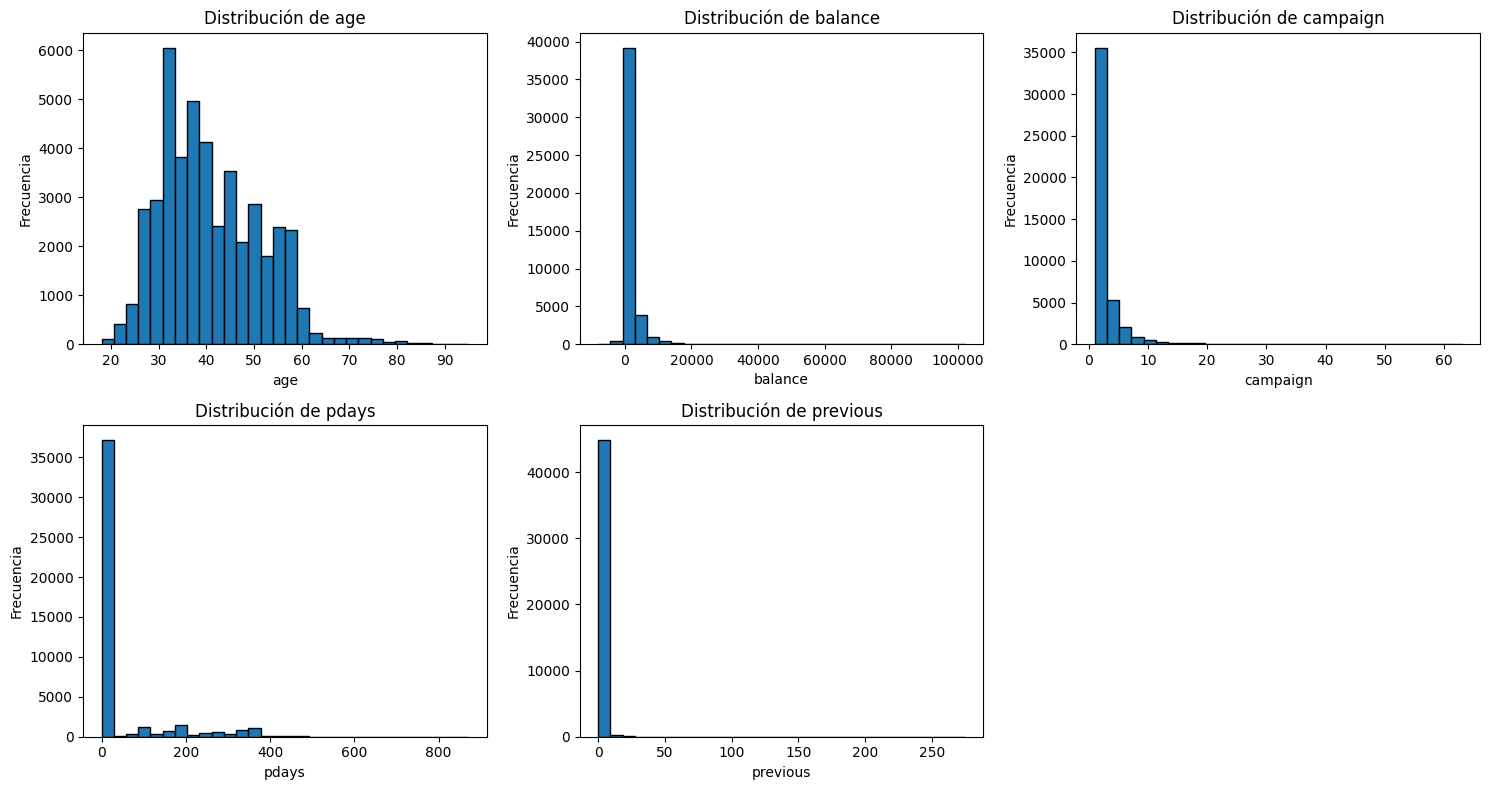

In [ ]:
#Identificación de Outliers

# Seleccionar variables numéricas
var_numeric = ['age', 'balance', 'campaign', 'pdays', 'previous']

# la distribuciones de las variables se presentan a continuación
fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # 2 filas, 3 columnas
axes = axes.flatten()

for i, var in enumerate(var_numeric):
    axes[i].hist(df2[var].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

# Ocultar el subplot vacío (sexto subplot)
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

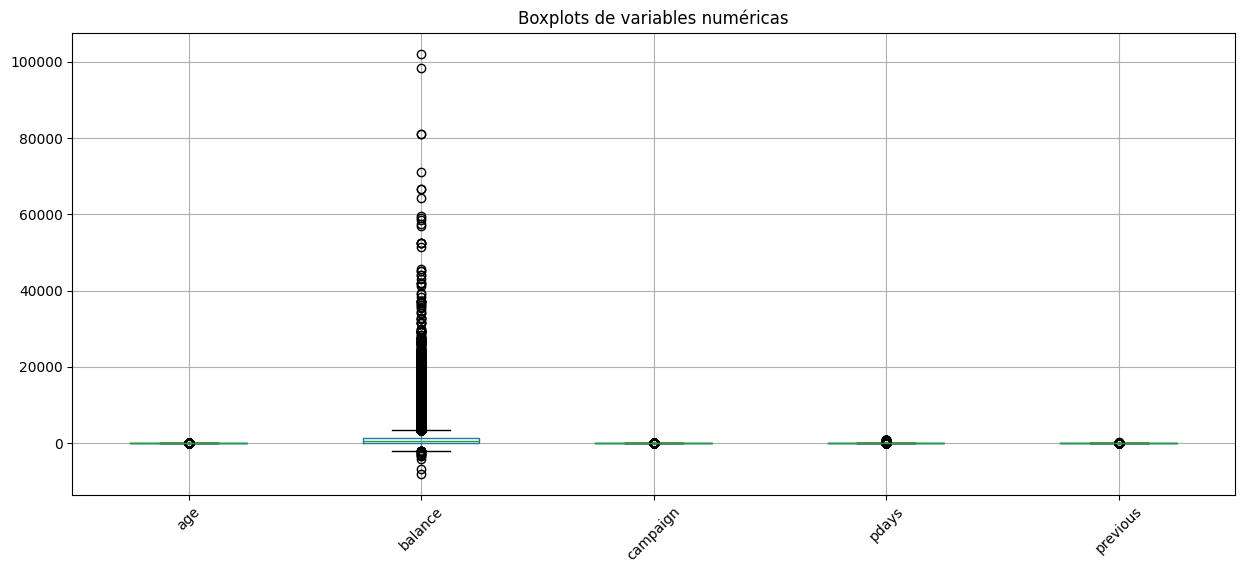

Cantidad de outliers por variable:
 age          487
balance     4729
campaign    3064
pdays       8257
previous    8257
dtype: int64


In [ ]:
# Visualizar outliers con boxplots
plt.figure(figsize=(15, 6))
df2[var_numeric].boxplot()
plt.title("Boxplots de variables numéricas")
plt.xticks(rotation=45)
plt.show()

# Identificar outliers con el método IQR
Q1 = df2[var_numeric].quantile(0.25)
Q3 = df2[var_numeric].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df2[var_numeric] < (Q1 - 1.5 * IQR)) | (df2[var_numeric] > (Q3 + 1.5 * IQR))).sum()
print("Cantidad de outliers por variable:\n", outliers)


In [ ]:
# Imputación de Outliers
for col in var_numeric:
    lower_bound = df2[col].quantile(0.05)
    upper_bound = df2[col].quantile(0.95)
    df2[col] = np.where(df2[col] < lower_bound, lower_bound, df2[col])
    df2[col] = np.where(df2[col] > upper_bound, upper_bound, df2[col])

print(df2.head())

    age           job  marital  education default  balance housing loan  \
0  58.0    management  married   tertiary      no   2143.0     yes   no   
1  44.0    technician   single  secondary      no     29.0     yes   no   
2  33.0  entrepreneur  married  secondary      no      2.0     yes  yes   
3  47.0   blue-collar  married  secondary      no   1506.0     yes   no   
4  33.0   blue-collar   single  secondary      no      1.0      no   no   

   day_of_week month  campaign  pdays  previous   y  
0            5   may       1.0   -1.0       0.0  no  
1            5   may       1.0   -1.0       0.0  no  
2            5   may       1.0   -1.0       0.0  no  
3            5   may       1.0   -1.0       0.0  no  
4            5   may       1.0   -1.0       0.0  no  


En el contexto de nuestro analisis sobre la predicción de la aceptación de depósitos a plazo, la imputación de outliers mediante los percentiles 5 y 95 se justifica estadisticamente para robustecer el modelo. Al acotar los valores extremos en variables numéricas como el saldo o el número de contactos, limitamos su influencia indebida en el aprendizaje del algoritmo. Esta técnica muestra cómo manejar datos atípicos sin descartar información valiosa, preservando la distribución central y mejorando la generalización del modelo al reducir la sensibilidad a observaciones atipicas.

## Feature Engineering

### Pregunta 1.4

 Cree un _pipeline_ de preprocesamiento con las siguientes transformaciones a las columnas correspondientes:

*   **Columnas Numéricas** : Aplique un `StandardScaler` para estandarizar estas variables.
*   **Columnas Categóricas No Binarias** : Aplique `OneHotEncoder` para crear variables dummy. Asegúrese de manejar posibles categorías desconocidas durante la transformación.
*   **Columnas a Eliminar** : Elimine columnas que dejan de ser relavantes luego de las trasformaciones.
*  **Columnas Dummies MultiNivel** : cree columnas dummies para las variables multi categoricas (tomando codificadas a 0s y 1s =, para su respctiva categoria)
*  **Columnas Label Encoding MultiNivel** : Dentro de las columnas multinivel hay 2 columnas que presentan un orden natural. e.g. en la columna 'month' tenemos que 'jan' < 'feb' < 'dec'. Aplique en la columna 'month' y otra columna que deberá determinar usted un label encoder que capture ese ordenamiento natural, luego normalice con un minmax scaler para que las columnas varien entre 0 y 1.


Una vez creado el pipeline, aplíquelo a su conjunto de features (`X`). Muestre la forma (_shape_) del dataset original y del dataset procesado para verificar los cambios. ¿Cuántas nuevas columnas hay?

Adicionalmente, elimine del análisis la variable `day_of_week`. Si considera necesario realizar transformaciones adicionales a las variables, realicelas en este punto.



In [ ]:
# Crear el transformador para estandarizar las variables numéricas
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Aplicar la transformación con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, var_numeric)
    ]
)

# Aplicar el pipeline al conjunto de datos
X_processed = preprocessor.fit_transform(df2)

# Convertir el resultado a DataFrame para visualizar
processed_df = pd.DataFrame(X_processed, columns=var_numeric)

# Mostrar primeras filas del dataset transformado
print(processed_df.head())


        age   balance  campaign     pdays  previous
0  1.777222  0.648845 -0.793438 -0.426599 -0.429644
1  0.333660 -0.688042 -0.793438 -0.426599 -0.429644
2 -0.800567 -0.705116 -0.793438 -0.426599 -0.429644
3  0.642995  0.246008 -0.793438 -0.426599 -0.429644
4 -0.800567 -0.705749 -0.793438 -0.426599 -0.429644


In [ ]:
# Definir las columnas categóricas binarias
binary_cols = ['default', 'housing', 'loan','y']

# Crear el transformador para OneHotEncoder
binary_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# Aplicar la transformación con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("binary", binary_transformer, binary_cols)
    ]
)

# Aplicar el pipeline al conjunto de datos
X_processed = preprocessor.fit_transform(df2)

# Convertir el resultado a DataFrame para visualizar
processed_df2 = pd.DataFrame(X_processed.toarray(), columns=preprocessor.get_feature_names_out())

# Mostrar primeras filas del dataset transformado
print(processed_df2.head())
print("Columnas generadas:", processed_df2.columns.tolist())


   binary__default_yes  binary__housing_yes  binary__loan_yes  binary__y_yes
0                  0.0                  1.0               0.0            0.0
1                  0.0                  1.0               0.0            0.0
2                  0.0                  1.0               1.0            0.0
3                  0.0                  1.0               0.0            0.0
4                  0.0                  0.0               0.0            0.0
Columnas generadas: ['binary__default_yes', 'binary__housing_yes', 'binary__loan_yes', 'binary__y_yes']


In [ ]:
# Definir las columnas multicategóricas
multi_cat_cols = ['job', 'education', 'marital', 'month']  # Ajusta según tu dataset

# Crear el transformador para OneHotEncoder
multi_cat_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Aplicar la transformación con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("multi_cat", multi_cat_transformer, multi_cat_cols)
    ]
)

# Aplicar el pipeline al conjunto de datos
X_processed = preprocessor.fit_transform(df2)

# Convertir el resultado a DataFrame para visualizar
processed_df3 = pd.DataFrame(X_processed.toarray(), columns=preprocessor.get_feature_names_out())

# Mostrar primeras filas del dataset transformado
print(processed_df3.head())
print("Columnas generadas:", processed_df3.columns.tolist())


   multi_cat__job_admin.  multi_cat__job_blue-collar  \
0                    0.0                         0.0   
1                    0.0                         0.0   
2                    0.0                         0.0   
3                    0.0                         1.0   
4                    0.0                         1.0   

   multi_cat__job_entrepreneur  multi_cat__job_housemaid  \
0                          0.0                       0.0   
1                          0.0                       0.0   
2                          1.0                       0.0   
3                          0.0                       0.0   
4                          0.0                       0.0   

   multi_cat__job_management  multi_cat__job_retired  \
0                        1.0                     0.0   
1                        0.0                     0.0   
2                        0.0                     0.0   
3                        0.0                     0.0   
4                     

In [ ]:
# Definir las columnas con orden natural
ordered_cols = ['month', 'education']

# Definir el orden de las categorías manualmente
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
education_order = ['primary', 'secondary', 'tertiary']

# Aplicar Label Encoding respetando el orden
df2['month_encoded'] = df2['month'].apply(lambda x: month_order.index(x))
df2['education_encoded'] = df2['education'].apply(lambda x: education_order.index(x))

# Crear el transformador para MinMaxScaler
scaler_transformer = Pipeline(steps=[
    ("scaler", MinMaxScaler())
])

# Aplicar la transformación con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("scaling", scaler_transformer, ['month_encoded', 'education_encoded'])
    ]
)

# Aplicar el pipeline al conjunto de datos
X_processed = preprocessor.fit_transform(df2)

# Convertir el resultado a DataFrame para visualizar
processed_df4 = pd.DataFrame(X_processed, columns=['month_scaled', 'education_scaled'])

# Mostrar primeras filas del dataset transformado
print(processed_df4.head())


   month_scaled  education_scaled
0      0.363636               1.0
1      0.363636               0.5
2      0.363636               0.5
3      0.363636               0.5
4      0.363636               0.5


In [ ]:
df_encoded = pd.concat([processed_df, processed_df2, processed_df3, processed_df4], axis=1)
print("Forma del dataset original:", df2.shape)
print("Forma del dataset procesado:", df_encoded.shape)
print("Número de nuevas columnas:", df_encoded.shape[1] - df2.shape[1])
df_encoded.info()

Forma del dataset original: (45211, 16)
Forma del dataset procesado: (45211, 40)
Número de nuevas columnas: 24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             45211 non-null  float64
 1   balance                         45211 non-null  float64
 2   campaign                        45211 non-null  float64
 3   pdays                           45211 non-null  float64
 4   previous                        45211 non-null  float64
 5   binary__default_yes             45211 non-null  float64
 6   binary__housing_yes             45211 non-null  float64
 7   binary__loan_yes                45211 non-null  float64
 8   binary__y_yes                   45211 non-null  float64
 9   multi_cat__job_admin.           45211 non-null  float64
 10  multi_cat__job_blue-collar      45211 non-n

Tras la transformación de las variables originales (numéricas, categóricas binarias y multicategóricas), se ha expandido el conjunto de datos a un total de 40 variables, incorporando 24 nuevas características.

## Modelos

En esta sección aplicaremos los algoritmos de clasificación vistos en el curso. Específicamente, compararemos el rendimiento de los siguientes modelos:

*   _Decision Tree Classifier_
*   _Random Forest Classifier_
*   _XGBoost Classifier_
*   _Naïve Bayes_



### Pregunta 1.5

Divida el conjunto de datos en conjuntos de entrenamiento y de prueba. Analice la distribución de la variable objetivo en ambos conjuntos para determinar si el conjunto de datos está balanceado o no.

En caso de que el conjunto de datos no esté balanceado, asegúrese de que la división de _train_-_test_ respete el balance de las clases target para evitar que se genere un sesgo. Para esto, se recomienda leer la documentación oficial de la función `train_test_split()`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html.

Use la semilla `random_state` = 123.


In [ ]:
from sklearn.model_selection import train_test_split

# Definir variable objetivo y características
y = df_encoded["binary__y_yes"]  # Variable objetivo
X = df_encoded.loc[:, df_encoded.columns != "binary__y_yes"]
# Variables predictoras

# División en entrenamiento y prueba con estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)

# Verificar distribución de clases en ambos conjuntos
print("Distribución en conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en conjunto de prueba:")
print(y_test.value_counts(normalize=True))


Distribución en conjunto de entrenamiento:
binary__y_yes
0.0    0.883022
1.0    0.116978
Name: proportion, dtype: float64

Distribución en conjunto de prueba:
binary__y_yes
0.0    0.882999
1.0    0.117001
Name: proportion, dtype: float64


Los resultados de la distribución de la variable objetivo en los conjuntos de entrenamiento y prueba son consistentes con la distribución observada en el conjunto de datos original. Esto confirma que la división estratificada ha preservado la proporción de las clases, asegurando que ambos subconjuntos reflejen el desbalance inherente de la variable objetivo, lo cual es fundamental para un modelado y evaluación imparciales.

### Pregunta 1.6

Entrene un árbol clasificador sin definir profundad máxima del árbol. Llamaremos a este, "modelo no regularizado".

Asegúrese de que el modelo sea capaz de lidiar con potenciales desbalances. Para esto se recomienda leer la documentación oficial de la *clase* `DecisionTreeClassifier()` (parámetros de inicialización): https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html.


Despliege el $F_1\ Score$ del modelo sobre la base de entrenamiento. Luego, grafique una representación del árbol entrenado. ¿Qué puede decir sobre este modelo no regularizado?

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Inicializar el modelo sin restricción de profundidad
modelo_no_regularizado = DecisionTreeClassifier(class_weight="balanced", random_state=123)

# Entrenar el modelo
modelo_no_regularizado.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=123)

In [ ]:
from sklearn.metrics import f1_score

# Predicciones en el conjunto de prueba
y_test_pred = modelo_no_regularizado.predict(X_test)

# Calcular el F1 Score
f1_test = f1_score(y_test, y_test_pred)
print(f"F1 Score en prueba: {f1_test:.4f}")

F1 Score en prueba: 0.2616


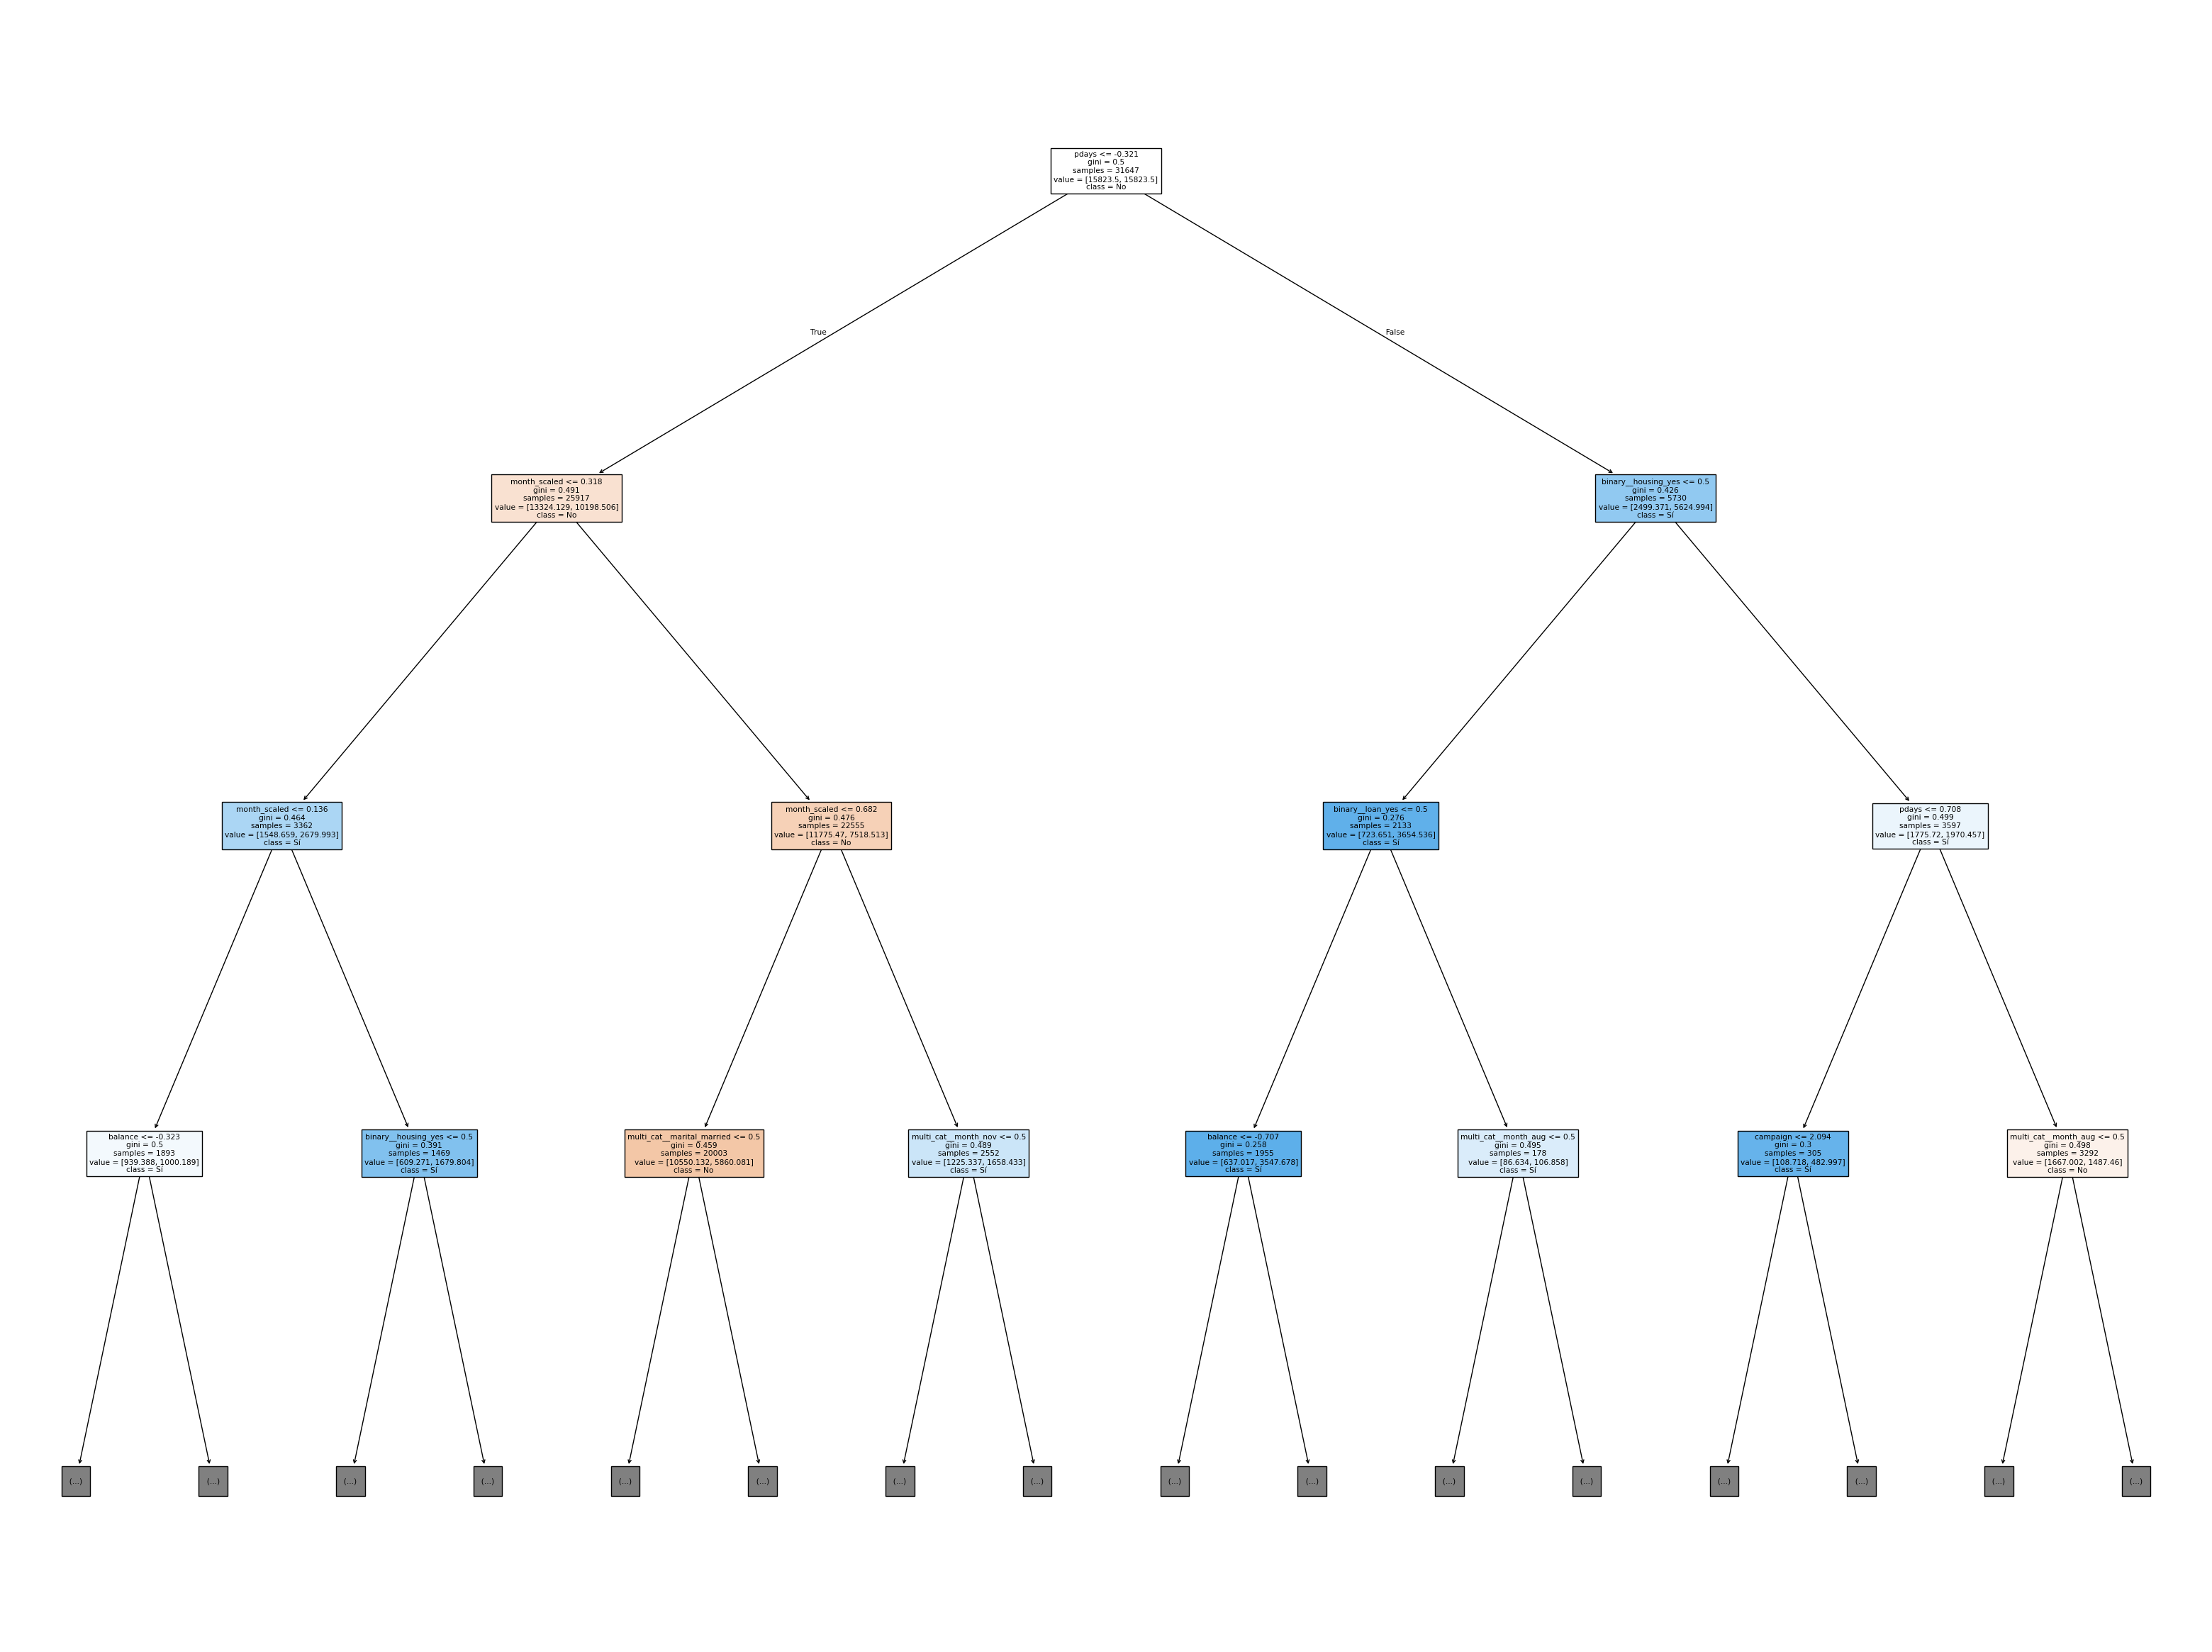

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(40,30))
plot_tree(modelo_no_regularizado, feature_names=X_train.columns, class_names=["No", "Sí"], filled=True, max_depth=3)
plt.show()

Dado un F1 Score en prueba de 0.2616, podemos inferir lo siguiente:

Bajo rendimiento en datos no vistos: El F1 Score relativamente bajo en el conjunto de prueba indica que el modelo no generaliza bien a datos nuevos. A pesar de que podría tener un rendimiento muy alto en el conjunto de entrenamiento, su capacidad predictiva en datos no vistos es limitada.


### Pegunta 1.7

En el contexto particular de una campaña de marketing, donde probablemente la mayoría de clientes no harán depósitos, es importante identificar correctamente tanto los clientes que harán depósitos (clase minoritaria), como los clientes que no harán depósitos.

En el primer caso, falsos negativos implican un cliente peridido. En el segundo caso, falsos positivos implicarían un gasto de marketing innecesario en clientes que no son de interés. En este sentido, si clasificamos a todos los clientes como individuos que no harán depósitos, el _accuracy_ será muy alto, pero el costo económico será muy grande.

Para penalizar tanto falsos positivos, como falsos negativos, a la vez que se busca maximizar los verdaderos positivos, nos enfocaremos en la métrica de _performance_ $F_1\ Score$.

Calcule el $F_1\ Score$ de su árbol no regularizado con la muestra correcta. ¿Considera que es un buen valor? Comente.

In [ ]:
from sklearn.metrics import f1_score

# Predicciones en el conjunto de prueba
y_test_pred = modelo_no_regularizado.predict(X_test)

# Calcular el F1 Score
f1_test = f1_score(y_test, y_test_pred)
print(f"F1 Score en prueba: {f1_test:.4f}")

F1 Score en prueba: 0.2616


se obtiene un F1 Score en prueba de 0.2616, por lo tanto, este modelo no regularizado no es adecuado para los objetivos de la campaña, y se requerirá aplicar técnicas de regularización o explorar otros modelos para mejorar su capacidad predictiva, especialmente para la clase minoritaria.


### Pregunta 1.8

Entrene un árbol clasificador con profundad máxima del árbol igual a 16. Llamaremos a este, "modelo levemente regularizado". Asegúrese de que el modelo sea capaz de lidiar con potenciales desbalances. Luego, despliege el $F_1\ Score$ del modelo sobre la base de entrenamiento.

Grafique una representación del árbol entrenado. ¿Qué puede decir sobre este modelo no regularizado?

In [ ]:
# Inicializar el modelo con max_depth=16 para regularización
modelo_levemente_regularizado = DecisionTreeClassifier(max_depth=16, class_weight="balanced", random_state=123)

# Entrenar el modelo
modelo_levemente_regularizado.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=16, random_state=123)

In [ ]:
# Predicciones en el conjunto de prueba
y_test_pred = modelo_levemente_regularizado.predict(X_test)

# Calcular el F1 Score
f1_test = f1_score(y_test, y_test_pred)
print(f"F1 Score en prueba: {f1_test:.4f}")

F1 Score en prueba: 0.3068


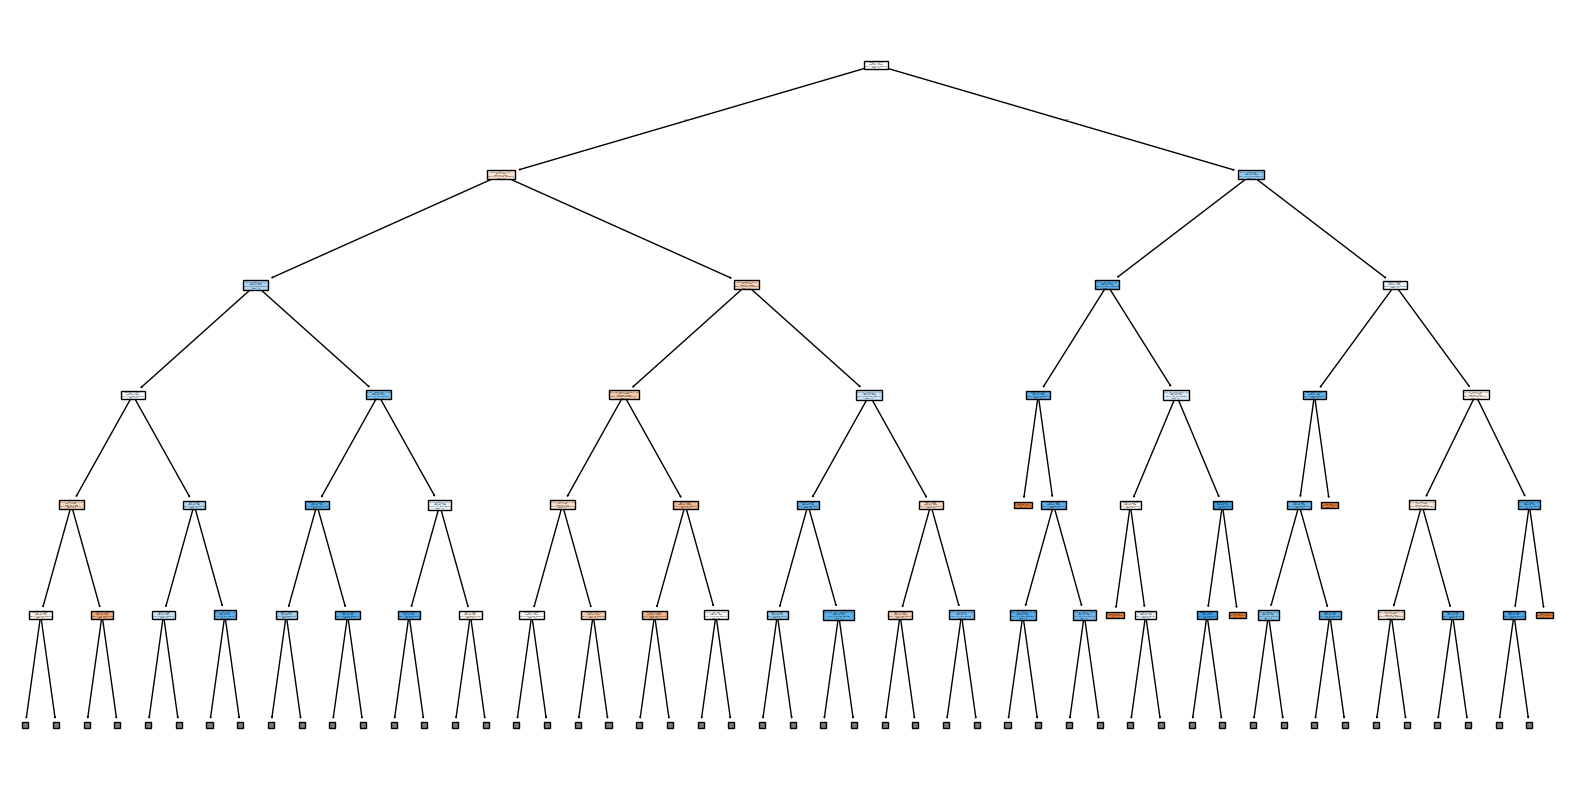

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(modelo_levemente_regularizado, feature_names=X_train.columns, class_names=["No", "Sí"], filled=True, max_depth=5)
plt.show()

Con la regularización, se observa una mejor generalización, lo cual se refleja en el aumento del F1 Score en prueba a 0.3068 desde el 0.2616 del modelo no regularizado.
La aplicación de una profundidad máxima de 16 al árbol de decisión ("modelo levemente regularizado") resultó en una mejor generalización en comparación con el modelo no regularizado, evidenciado por un aumento del F1 Score en prueba de 0.2616 a 0.3068. Esta regularización ayuda a prevenir el sobreajuste, generando predicciones más robustas y una mejor identificación de los clientes potenciales para depósitos a plazo. Aunque el árbol sigue siendo complejo, la limitación de profundidad mejora su capacidad para generalizar a nuevos datos.

### Pregunta 1.9

Entrene un árbol clasificador con profundad máxima del árbol igual a 8. Llamaremos a este, "modelo regularizado". Asegúrese de que el modelo sea capaz de lidiar con potenciales desbalances. Luego, despliege el $F_1\ Score$ del modelo sobre la base de entrenamiento.

Grafique una representación del árbol entrenado. ¿Qué puede decir sobre este modelo no regularizado?


F1 Score en prueba: 0.3817


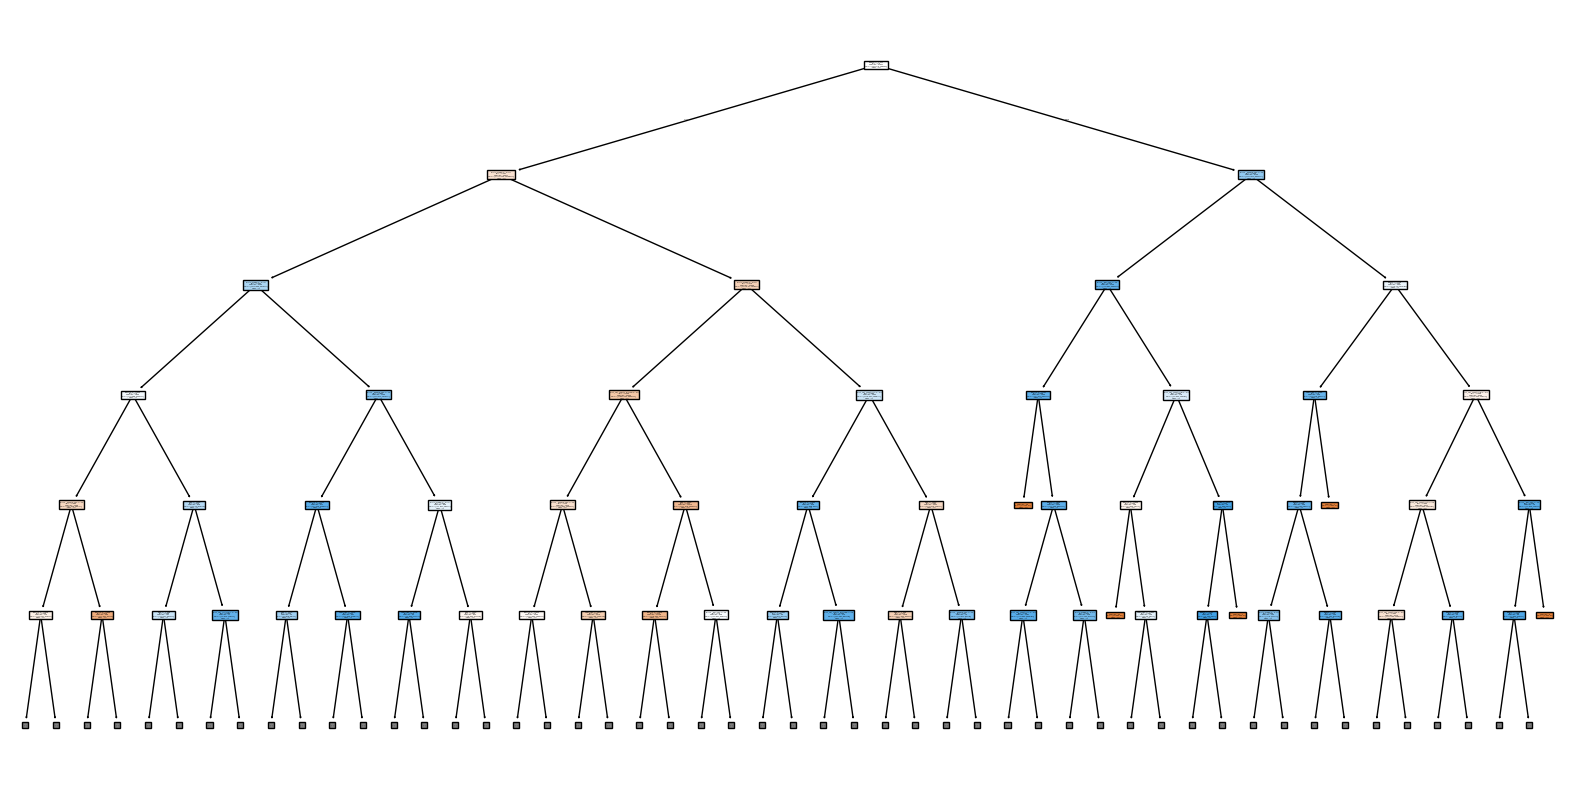

In [ ]:
from sklearn.tree import plot_tree
# Inicializar el modelo con max_depth=8 para regularización
modelo_regularizado = DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=123)

# Entrenar el modelo
modelo_regularizado.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_test_pred = modelo_regularizado.predict(X_test)

# Calcular el F1 Score
f1_test = f1_score(y_test, y_test_pred)
print(f"F1 Score en prueba: {f1_test:.4f}")

plt.figure(figsize=(20,10))
plot_tree(modelo_regularizado, feature_names=X_train.columns, class_names=["No", "Sí"], filled=True, max_depth=5)
plt.show()


Al limitar la profundidad máxima del árbol a 8 ("modelo regularizado"), se observa una mejora significativa en la generalización, con un F1 Score en prueba que aumentó a 0.3817 desde 0.3068. Esta mayor regularización conduce a un modelo menos complejo y con menor sobreajuste, lo que resulta en una mejor capacidad para predecir la aceptación de depósitos a plazo en nuevos clientes.

### Pregunta 1.10

Entrene 20 árboles de clasificación. Cada uno de ellos debe estar entrenado fijando la profundidad máxima del árbol `max_depth` igual a $n \in [1,20]$. Obtenga el $F_1\ Score$ de cada árbol con la base de entrenamiento y la base de prueba.

Gafique en una misma figura $F_1\ Score$ de entrenamiento contra $n$ y $F_1\ Score$ de prueba contra $n$ (Eje X = $n$). ¿Cuál parece ser el parámetro óptimo $n^*$ para el árbol? ¿Qué puede decir sobre el parámetro sobre _overfitting_ y generalización?

In [ ]:
# Definir el rango de profundidades
max_depth_values = range(1, 21)

# Listas para almacenar los F1 Scores
f1_train_scores = []
f1_test_scores = []

# Entrenar modelos con diferentes profundidades
for depth in max_depth_values:
    modelo = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=123)
    modelo.fit(X_train, y_train)

    # Predicciones
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)

    # Calcular F1 Score
    f1_train_scores.append(f1_score(y_train, y_train_pred))
    f1_test_scores.append(f1_score(y_test, y_test_pred))

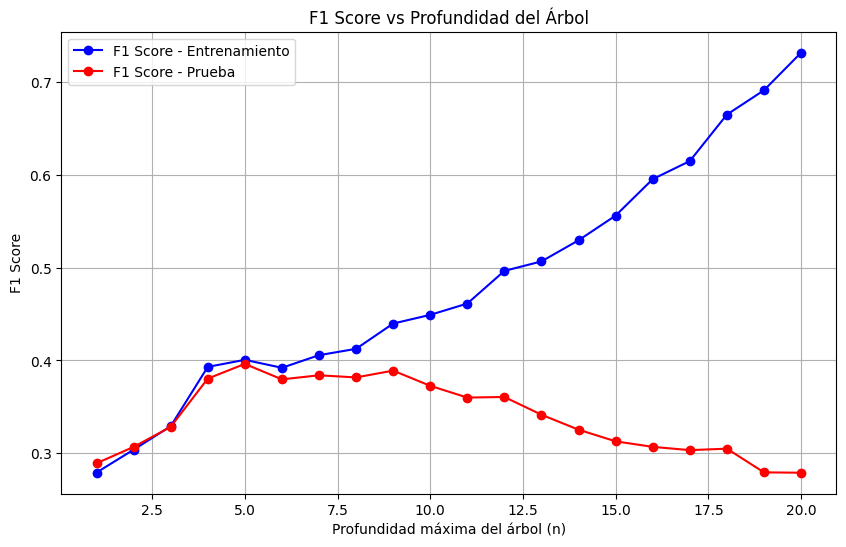

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(max_depth_values, f1_train_scores, marker='o', label="F1 Score - Entrenamiento", color="blue")
plt.plot(max_depth_values, f1_test_scores, marker='o', label="F1 Score - Prueba", color="red")
plt.xlabel("Profundidad máxima del árbol (n)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Profundidad del Árbol")
plt.legend()
plt.grid()
plt.show()

El gráfico del F1 Score versus la profundidad máxima del árbol (n) revela la dinámica entre ajuste y generalización. El F1 Score en entrenamiento aumenta consistentemente con n, indicando un mejor ajuste a los datos de entrenamiento. Sin embargo, el F1 Score en prueba inicialmente crece y luego decrece, señalando el punto donde el sobreajuste comienza a deteriorar la capacidad de generalización. El parámetro óptimo n parece situarse alrededor de 9 o 10, donde el F1 Score en prueba alcanza su máximo. Valores bajos de n causan underfitting, mientras que valores altos provocan overfitting.
El objetivo es hallar el n que maximice el rendimiento en datos no vistos, logrando un equilibrio óptimo entre la complejidad del modelo y su habilidad para generalizar de manera efectiva en la predicción de depósitos a plazo.

### Pregunta 1.11

En esta pregunta deberá entrenar _Random orest Classifier_ realizando un ejercicio previo de _hyperparameter tuning_.

Realice _Cross Validation_ con un _folding_ con `K=5` y calcule $F_1\ Score$ de todas las posibles combinaciones de los siguientes parámetros:

- `n_estimators = {100, 1000}`
- `max_depth = {10, 50, 100}`
- `min_samples_leaf = {2, 4}`

Determine la mejor combinación de parámetros y vuelva a entrenar su bosque con esta. Finalmente, reporte el $F_1\ Score$ con la muestra de prueba.

Cuando realice _Cross Validation_ y cuando entrene el modelo final, asegúrese de que el modelo sea capaz de lidiar con potenciales desbalances. Para esto se recomienda leer la documentación oficial de la *clase* `RandomForestClassifier()` (parámetros de inicialización): https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import f1_score

param_grid = {
    "n_estimators": [100, 1000],
    "max_depth": [10, 50, 100],
    "min_samples_leaf": [2, 4]
}

# Inicializar el modelo
modelo_rf = RandomForestClassifier(class_weight="balanced", random_state=123)

# Grid Search con validación cruzada
grid_search = GridSearchCV(modelo_rf, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Mejor combinación de hiperparámetros
mejores_params = grid_search.best_params_
print("Mejores hiperparámetros:", mejores_params)


modelo_optimo = RandomForestClassifier(**mejores_params, class_weight="balanced", random_state=123)
modelo_optimo.fit(X_train, y_train)

y_test_pred = modelo_optimo.predict(X_test)
f1_test = f1_score(y_test, y_test_pred)
print(f"F1 Score en prueba: {f1_test:.4f}")


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores hiperparámetros: {'max_depth': 50, 'min_samples_leaf': 4, 'n_estimators': 1000}
F1 Score en prueba: 0.4481


Como resultado, el modelo exhibe una capacidad predictiva significativamente superior, la mejora significativa en el F1 Score al pasar de un árbol de decisión regularizado a un Random Forest optimizado se debe a la naturaleza del Random Forest como un ensamble de múltiples árboles de decisión. Esta técnica reduce el sobreajuste y la varianza al incorporar muestreo aleatorio tanto en los datos como en las características, lo que permite generar un modelo más robusto y generalizable para predecir la aceptación de depósitos a plazo.

### Pregunta 1.12

En esta pregunta deberá entrenar _XGBpost Classifier_ realizando un ejercicio previo de _hyperparameter tuning_.

Repita el ejercicio de _Cross Validation_ anterior, pero está vez evaluando:

- `n_estimators = {100, 1000}`
- `max_depth = {5, 50, 100}`
- `learning_rate = {0.05, 0.1, 0.5}`
- `max_leaves= {2, 4, 10}`

Determine la mejor combinación de parámetros y vuelva a entrenar su bosque con esta, reportando el $F_1\ Score$ con la muestra de prueba.

Asegúrese de que sus modelos sean capaces de lidiar con potenciales desbalances. Para esto se recomienda leer la documentación oficial de la *clase* `XGBClassifier()` (parámetros de inicialización): https://xgboost.readthedocs.io/en/latest/python/python_api.html.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

param_grid = {
    "n_estimators": [100, 1000],
    "max_depth": [5, 50, 100],
    "learning_rate": [0.05, 0.1, 0.5],
    "max_leaves": [2, 4, 10]
}

# Inicializar el modelo
modelo_xgb = XGBClassifier(scale_pos_weight=2, random_state=123)

# Grid Search con validación cruzada
grid_search = GridSearchCV(modelo_xgb, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

# Mejor combinación de hiperparámetros
mejores_params = grid_search.best_params_
print("Mejores hiperparámetros:", mejores_params)

##Entrenar modelo

modelo_optimo = XGBClassifier(**mejores_params, scale_pos_weight=2, random_state=123)
modelo_optimo.fit(X_train, y_train)


y_test_pred = modelo_optimo.predict(X_test)
f1_test = f1_score(y_test, y_test_pred)
print(f"F1 Score en prueba: {f1_test:.4f}")


Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 5, 'max_leaves': 10, 'n_estimators': 1000}
F1 Score en prueba: 0.4018


### Pregunta 1.13

Entrene un modelo _Naïve Bayes_. Asegúrese de que el modelo sea capaz de lidiar con potenciales desbalances. Para esto se recomienda leer la documentación oficial de la *clase* `GaussianNB()` (parámetros de inicialización): https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html.


Despliege el $F_1\ Score$ del modelo sobre la base de entrenamiento.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score

# Inicializar el modelo Naïve Bayes
modelo_nb = GaussianNB()

# Entrenar el modelo
modelo_nb.fit(X_train, y_train)

# Predicciones en el conjunto de entrenamiento
y_train_pred = modelo_nb.predict(X_train)

# Calcular el F1 Score
f1_train = f1_score(y_train, y_train_pred)
print(f"F1 Score en entrenamiento: {f1_train:.4f}")


F1 Score en entrenamiento: 0.3436




---



En comparación con el Random Forest cuyo F1 Score fue de 0.4481, el rendimiento del XGBoost con la mejor combinación de parámetros es ligeramente inferior en este caso. Esto podría deberse a la especificidad de los datos y la optimización realizada para cada algoritmo.

## Análisis Comparativo de Modelos de Clasificación


### Pregunta 1.14

Evalúe y compare el desempeño de los modelos teniendo en cuenta la naturaleza del conjunto de datos. ¿Cómo afectó el desbalance a cada modelo? ¿Qué modelo manejó mejor el balance o desbalance de clases y cuáles son sus conclusiones generales sobre su rendimiento comparado?

Para que la comparación sea clara, es útil indicar qué métricas de evaluación utilizo para comparar los modelos (por ejemplo, F1-score, precisión, recall, AUC, etc.).

Para evaluar el rendimiento de los modelos en la predicción de la aceptación de depósitos a plazo, se utilizó principalmente el F1 Score, una métrica crucial en conjuntos de datos desbalanceados. El árbol de decisión no regularizado obtuvo el F1 Score más bajo (0.2616), mostrando ser sensible al desbalance. La introducción de regularización en los árboles de decisión (profundidades máximas de 16 y 8) mejoró gradualmente el F1 Score en prueba (0.3068 y 0.3817 respectivamente), indicando una mejor generalización y manejo del desbalance al usar class_weight='balanced'.

Los modelos de ensamble superaron a los árboles individuales. El Random Forest optimizado logró el F1 Score más alto (0.4481), demostrando una excelente capacidad para equilibrar precisión y recall en la identificación de los potenciales depositantes. XGBoost, también optimizado para el desbalance, obtuvo un F1 Score de 0.4018, ligeramente inferior al Random Forest pero superior a los árboles de decisión regularizados.

En conclusión, los modelos de ensamble, particularmente el Random Forest, manejaron mejor el desbalance del conjunto de datos, proporcionando un rendimiento predictivo superior para la tarea de la campaña de marketing de depósitos a plazo. La combinación de múltiples modelos y la aleatoriedad inherente en Random Forest parecen ser más efectivas para este tipo de problema.


# KMeans & PCA

La guerra comercial desatada levanta un montón de preguntas de interés en economía. Una de estas es: ¿Qué países sufrirán de forma similar las consecuencias de esta? ¿Quiénes serían ganadores? ¿Quienes serían perdedores?

En esta parte exploraremos el aporte que los métodos de Clustering de Machine Learning pueden hacer a la respuesta de esta cuestión. Nos enfocaremos en variables relacionadas al comercio exterior para determinar similitud entre grupos de países. Más específicamente, en variables relacionadas a las exportaciones.

Para esto, considere las siguientes variables que describen el perfil exportador de cada país:

- GDP growth (annual %)
- Agricultural raw materials exports (% of merchandise exports)
- Computer, communications and other services (% of commercial service exports)
- Exports of goods and services (% of GDP)
- Food exports (% of merchandise exports)
- Fuel exports (% of merchandise exports)
- High-technology exports (% of manufactured exports)
- ICT service exports (% of service exports, BoP)
- Insurance and financial services (% of service exports, BoP)
- International tourism, receipts (% of total exports)
- Manufactures exports (% of merchandise exports)
- Merchandise exports to high-income economies (% of total merchandise exports)
- Merchandise exports to low- and middle-income economies in Europe & Central Asia (% of total merchandise exports)
- Ores and metals exports (% of merchandise exports)
- Taxes on exports (% of tax revenue)
- Transport services (% of commercial service exports)


La idea será determinar similitud entre países y las variables qué son más relevantes a la hora de determinarla.

Debido a que 2023 es el año reciente con una mayor riqueza de datos, y debido a que nos interesan cambios respecto al _status quo_ en el contexto actual, trabajaremos con datos sólo de aquel año.

Database Source: World bank & Trade Analysis Information System.



### Pregunta 2.0

Cargue la base de datos disponible en el siguiente link: https://raw.githubusercontent.com/olherreragz/EAE3709-2025-1/refs/heads/main/T2_data/Data.cs.

En el siguiente link podrá encontrar información adicional sobre el _dataset_ por si lo llega a necesitar: https://github.com/olherreragz/EAE3709-2025-1/blob/main/T2_data/Series_Metadata.csv.

Elimine las columnas `"Series Code"` y `"Country Code"`. Luego, transforme su _dataframe_ de formato _Long_ a _Wide_. Su _dataframe_ final deberá contener una columna que indique el nombre del país y columnas que indiquen la medida de exportación correspondiente:

`<Country>, <SeriesName1>, <SeriesName2> ....`



![Long to Wide Format](https://tavareshugo.github.io/r-intro-tidyverse-gapminder/fig/07-data_shapes.png)




In [ ]:
# DESCARGAMOS EL ARCHIVO DEL URL
url = "https://raw.githubusercontent.com/olherreragz/EAE3709-2025-1/main/T2_data/Data.csv"
data_set2 = pd.read_csv(url)

# Eliminar columnas no necesarias
data_set2 = data_set2.drop(['Series Code', 'Country Code'], axis=1)

# Transformar de long a wide
data_wide = data_set2.pivot(index='Country Name', columns='Series Name', values='2023 [YR2023]')

data_wide.head()

Series Name,Agricultural raw materials exports (% of merchandise exports),Computer; communications and other services (% of commercial service exports),Exports of goods and services (% of GDP),Food exports (% of merchandise exports),Fuel exports (% of merchandise exports),GDP growth (annual %),High-technology exports (% of manufactured exports),ICT service exports (% of service exports; BoP),Insurance and financial services (% of service exports; BoP),International tourism; receipts (% of total exports),Manufactures exports (% of merchandise exports),Merchandise exports to high-income economies (% of total merchandise exports),Merchandise exports to low- and middle-income economies in Europe & Central Asia (% of total merchandise exports),Ores and metals exports (% of merchandise exports),Taxes on exports (% of tax revenue),Transport services (% of commercial service exports)
Country Name,,,,,,,,,,,,,,,,
Afghanistan,..,..,16.7751362822863,..,..,2.71088679128353,..,..,..,..,..,12.8798269363707,9.68241869729934,..,..,..
Africa Eastern and Southern,1.93287526195653,35.9298385263195,24.3483372544611,14.285851632509,25.4254224001233,2.32013780158925,5.80516538196113,6.10657347896149,6.08028700896879,..,29.1304853698777,44.3959450802976,0.471789673271105,23.4925994471713,..,22.9754549072797
Africa Western and Central,3.80482687815641,23.7057568350145,..,12.9874441377748,61.3705691120184,3.3547328190002,..,5.69176863421842,14.9934752391386,..,6.76897203140647,54.1428772898838,3.17153807284374,4.3390849886261,..,36.2200117483328
Albania,0.406032063201426,24.4301090197124,38.6650817896799,11.9640780632637,6.34538423879421,3.93662525742167,0.682326849473647,3.01397608748124,0.662505307988438,..,56.6139655531231,77.7081307571647,19.5159727248964,5.34944752843742,..,10.9287529629646
Algeria,..,59.1626427564765,23.6195363708424,..,..,4.10000000000004,..,2.21311390791552,10.2830758414755,..,..,80.1800299622258,6.36723723188521,..,..,25.4709095419937


### Pregunta 2.1

Debido a que la pregunta de interés es sobre identificación de grupos de países, elime filas donde `Country Name` sea igual a cualquiera de los siguientes valores:

- "Africa Eastern and Southern"  
- "Africa Western and Central"  
- "Arab World"  
- "Caribbean small states"  
- "Central Europe and the Baltics"  
- "Early-demographic dividend"  
- "East Asia & Pacific"  
- "East Asia & Pacific (IDA & IBRD countries)"  
- "East Asia & Pacific (excluding high income)"  
- "Euro area"  
- "Europe & Central Asia"  
- "Europe & Central Asia (IDA & IBRD countries)"  
- "Europe & Central Asia (excluding high income)"  
- "European Union"  
- "Fragile and conflict affected situations"  
- "Heavily indebted poor countries (HIPC)"  
- "High income"  
- "IBRD only"  
- "IDA & IBRD total"  
- "IDA blend"  
- "IDA only"  
- "IDA total"  
- "Late-demographic dividend"  
- "Latin America & Caribbean"  
- "Latin America & Caribbean (excluding high income)"  
- "Latin America & the Caribbean (IDA & IBRD countries)"  
- "Least developed countries: UN classification"  
- "Low & middle income"  
- "Low income"  
- "Lower middle income"  
- "Middle East & North Africa"  
- "Middle East & North Africa (IDA & IBRD countries)"  
- "Middle East & North Africa (excluding high income)"  
- "Middle income"  
- "North America"  
- "Not classified"  
- "OECD members"  
- "Other small states"  
- "Pacific island small states"  
- "Post-demographic dividend"  
- "Pre-demographic dividend"  
- "Small states"  
- "South Asia"  
- "South Asia (IDA & IBRD)"  
- "Sub-Saharan Africa"  
- "Sub-Saharan Africa (IDA & IBRD countries)"  
- "Sub-Saharan Africa (excluding high income)"  
- "Upper middle income"  
- "World"




In [ ]:
# Regiones a eliminar
regiones_a_eliminar = [
    "Africa Eastern and Southern", "Africa Western and Central", "Arab World",
    "Caribbean small states", "Central Europe and the Baltics", "Early-demographic dividend",
    "East Asia & Pacific", "East Asia & Pacific (IDA & IBRD countries)",
    "East Asia & Pacific (excluding high income)", "Euro area", "Europe & Central Asia",
    "Europe & Central Asia (IDA & IBRD countries)", "Europe & Central Asia (excluding high income)",
    "European Union", "Fragile and conflict affected situations",
    "Heavily indebted poor countries (HIPC)", "High income", "IBRD only",
    "IDA & IBRD total", "IDA blend", "IDA only", "IDA total", "Late-demographic dividend",
    "Latin America & Caribbean", "Latin America & Caribbean (excluding high income)",
    "Latin America & the Caribbean (IDA & IBRD countries)",
    "Least developed countries: UN classification", "Low & middle income", "Low income",
    "Lower middle income", "Middle East & North Africa",
    "Middle East & North Africa (IDA & IBRD countries)",
    "Middle East & North Africa (excluding high income)", "Middle income", "North America",
    "Not classified", "OECD members", "Other small states", "Pacific island small states",
    "Post-demographic dividend", "Pre-demographic dividend", "Small states", "South Asia",
    "South Asia (IDA & IBRD)", "Sub-Saharan Africa", "Sub-Saharan Africa (IDA & IBRD countries)",
    "Sub-Saharan Africa (excluding high income)", "Upper middle income", "World"
]

# Filtrar solo países
data_paises = data_wide[~data_wide.index.isin(regiones_a_eliminar)]
data_paises.head(10)

Series Name,Agricultural raw materials exports (% of merchandise exports),Computer; communications and other services (% of commercial service exports),Exports of goods and services (% of GDP),Food exports (% of merchandise exports),Fuel exports (% of merchandise exports),GDP growth (annual %),High-technology exports (% of manufactured exports),ICT service exports (% of service exports; BoP),Insurance and financial services (% of service exports; BoP),International tourism; receipts (% of total exports),Manufactures exports (% of merchandise exports),Merchandise exports to high-income economies (% of total merchandise exports),Merchandise exports to low- and middle-income economies in Europe & Central Asia (% of total merchandise exports),Ores and metals exports (% of merchandise exports),Taxes on exports (% of tax revenue),Transport services (% of commercial service exports)
Country Name,,,,,,,,,,,,,,,,
Afghanistan,..,..,16.7751362822863,..,..,2.71088679128353,..,..,..,..,..,12.8798269363707,9.68241869729934,..,..,..
Albania,0.406032063201426,24.4301090197124,38.6650817896799,11.9640780632637,6.34538423879421,3.93662525742167,0.682326849473647,3.01397608748124,0.662505307988438,..,56.6139655531231,77.7081307571647,19.5159727248964,5.34944752843742,..,10.9287529629646
Algeria,..,59.1626427564765,23.6195363708424,..,..,4.10000000000004,..,2.21311390791552,10.2830758414755,..,..,80.1800299622258,6.36723723188521,..,..,25.4709095419937
American Samoa,..,..,..,..,..,..,..,..,..,..,..,73.1557182839582,0.7485445254755,..,..,..
Andorra,0.415383101399855,12.8811837923156,..,1.0898638304214,0.0101475994472374,2.58355480961319,21.4346319155008,4.34892555438222,3.72824437871563,..,94.9903929863838,..,..,1.77400635480091,..,1.65464266165053
Angola,0.0027480777886125,59.4391641118594,40.8567793904075,0.451668885477411,94.1710862801417,1.00128936028298,23.4714139423334,45.4147601334516,..,..,1.02737042810773,34.3574616999776,0.0309878743509611,4.34074978568308,..,30.6375045277801
Antigua and Barbuda,0,5.8813262062607,..,79.5397138175244,0,3.86201218730389,0,0.491266592127263,5.80948318370139,..,20.4603069224402,88.6247722258341,0.130578254598856,0,..,5.48300642645932
Argentina,0.685733538526298,51.6794119050265,12.7492457826544,52.7267666905217,8.81364245499018,-1.61100162090189,5.44959440578319,15.2012582416621,1.41230813564913,..,18.949952599116,40.934692199854,1.07227775774405,0.39379723312782,..,12.4292640727332
Armenia,0.355694680218345,25.6334543063376,59.4520856749187,13.1574500307472,0.907565586250454,8.29999999959539,21.1051280159346,18.8731728802376,5.23008643389089,..,48.165424198542,86.1275075443156,4.72029050452744,14.9723565110048,..,15.9022004689825


### Pregunta 2.2

Reemplace todos los valores `".."` por `NA`. Luego, transforme las columnas a variables numéricas y despliegue estadísticas descriptivas.


In [ ]:
# Reemplazar ".." por NA
data_paises = data_paises.replace('..', np.nan)

# Convertimos variables a numéricas
data_paises = data_paises.apply(pd.to_numeric)

# Estadísticas descriptivas
data_paises.describe()

<ipython-input-209-4584f994150d>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_paises = data_paises.replace('..', np.nan)


Series Name,Agricultural raw materials exports (% of merchandise exports),Computer; communications and other services (% of commercial service exports),Exports of goods and services (% of GDP),Food exports (% of merchandise exports),Fuel exports (% of merchandise exports),GDP growth (annual %),High-technology exports (% of manufactured exports),ICT service exports (% of service exports; BoP),Insurance and financial services (% of service exports; BoP),International tourism; receipts (% of total exports),Manufactures exports (% of merchandise exports),Merchandise exports to high-income economies (% of total merchandise exports),Merchandise exports to low- and middle-income economies in Europe & Central Asia (% of total merchandise exports),Ores and metals exports (% of merchandise exports),Taxes on exports (% of tax revenue),Transport services (% of commercial service exports)
count,149.000000,161.000000,158.000000,149.000000,145.000000,195.000000,147.000000,157.000000,152.000000,0.0,149.000000,205.000000,192.000000,149.000000,22.000000,161.000000
mean,2.726255,35.005284,45.398868,24.136526,14.275881,3.241160,11.352849,10.234009,5.732781,NaN,42.098438,60.914241,5.096570,9.476862,2.624425,20.583359
std,7.416283,23.550764,33.331007,23.862474,23.215387,6.641153,13.507894,11.534976,7.703914,NaN,29.236666,24.978469,11.628976,15.470820,4.899022,16.870115
min,0.000000,0.935706,1.108109,0.079874,0.000000,-20.111576,0.000000,0.043145,0.008135,NaN,0.210353,0.121224,0.000034,0.000000,0.000002,0.663447
25%,0.343928,13.309551,23.637110,8.338115,0.498740,1.168088,2.226174,2.681207,1.319000,NaN,15.347126,43.902677,0.244645,1.353868,0.046153,7.784412
50%,0.794963,32.273353,38.790357,15.056512,4.097826,2.960181,6.030929,7.285006,3.203366,NaN,37.251121,65.682415,0.942470,3.138350,0.232860,15.739129
75%,2.120083,53.862266,56.494967,32.790842,15.770449,4.987486,16.841983,12.745838,7.163361,NaN,68.665103,82.370504,3.269713,8.391231,1.419763,27.632283
max,63.703068,95.860793,212.530618,98.210416,95.516439,75.061377,72.315489,61.766896,55.672826,NaN,94.990393,97.770966,96.949670,76.471800,15.578989,86.950670


In [ ]:
# Información de Variables
data_paises.info()

<class 'pandas.core.frame.DataFrame'>
Index: 217 entries, Afghanistan to Zimbabwe
Data columns (total 16 columns):
 #   Column                                                                                                             Non-Null Count  Dtype  
---  ------                                                                                                             --------------  -----  
 0   Agricultural raw materials exports (% of merchandise exports)                                                      149 non-null    float64
 1   Computer; communications and other services (% of commercial service exports)                                      161 non-null    float64
 2   Exports of goods and services (% of GDP)                                                                           158 non-null    float64
 3   Food exports (% of merchandise exports)                                                                            149 non-null    float64
 4   Fuel exports (% 

### Pregunta 2.3

Grafique la distribución empírica de todas las variables numéricas del dataset. Comente sobre cada una de ellas.

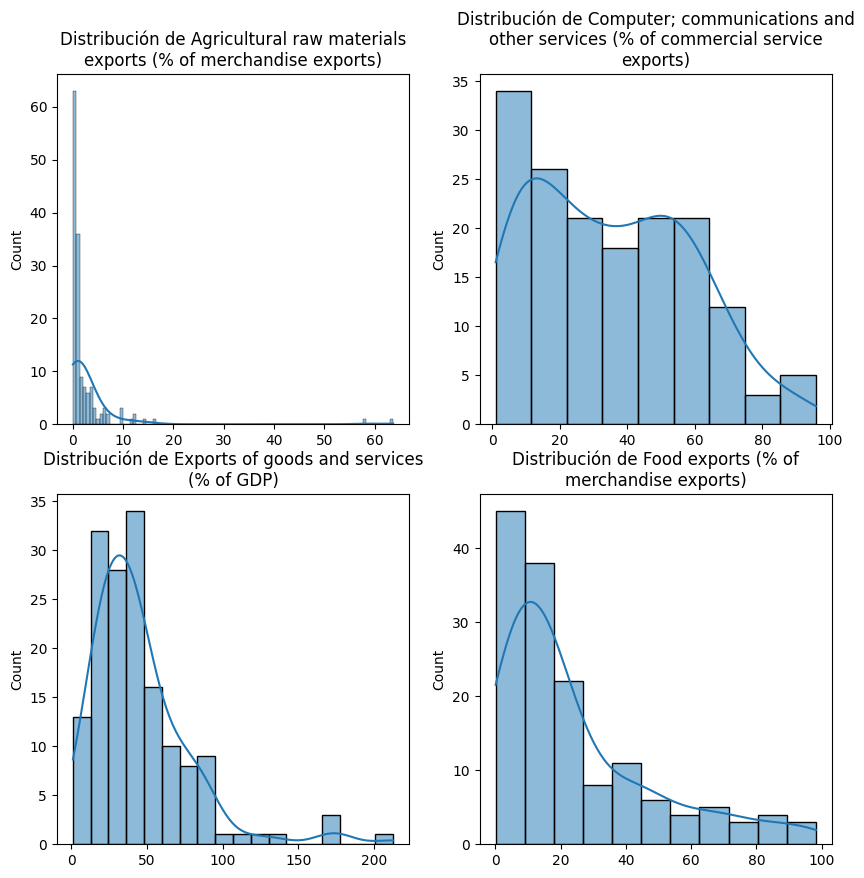

In [ ]:
# Graficar distribuciones
group1=['Agricultural raw materials exports (% of merchandise exports)',
        'Computer; communications and other services (% of commercial service exports)',
        'Exports of goods and services (% of GDP)',
        'Food exports (% of merchandise exports)']
# Creamos subplots, para comninar varios graficos en una sola imagen
fig, axes = plt.subplots(2,2, figsize=(10, 10))
# Creamos loop que genere histograma para cada variable
for i, var in enumerate(group1):
    row = i // 2
    col = i % 2
    sns.histplot(data_paises[var],kde=True, ax=axes[row, col])
    wrapped_title = textwrap.fill(f'Distribución de {var}', width=45)
    axes[row, col].set_title(wrapped_title)
    axes[row, col].set_xlabel('')




---
Podemos obserar que:
*   La variable de exportaciones agricolas presenta una distribución extremadamente sesgada hacia la derecha, con la mayoria de paises de la muestra con porcentajes al rededor del 0%.
*  La variable de Computadoras y servicios de comunciación (como porcentaje de exportación de bienes de servico) tiene una distribución ligeramente sesgada hacia la derecha, con los puntos de mayor aculuación a rededor de los valores de 10% y 50%.
*  La variable de Exportaciones de bienes y servicos (como porcentaje del PBI) tiene una distribución ligeramente sesgada hacia la derecha, on la mayoria de paises de la muestra con porcentajes al rededor del 10% y 40% (en una escala por encima del 100%)
*   La variable de exportaciones de alimentos presenta una distribución  sesgada hacia la derecha, con la mayoria de paises de la muestra con porcentajes al rededor del 10%.






---


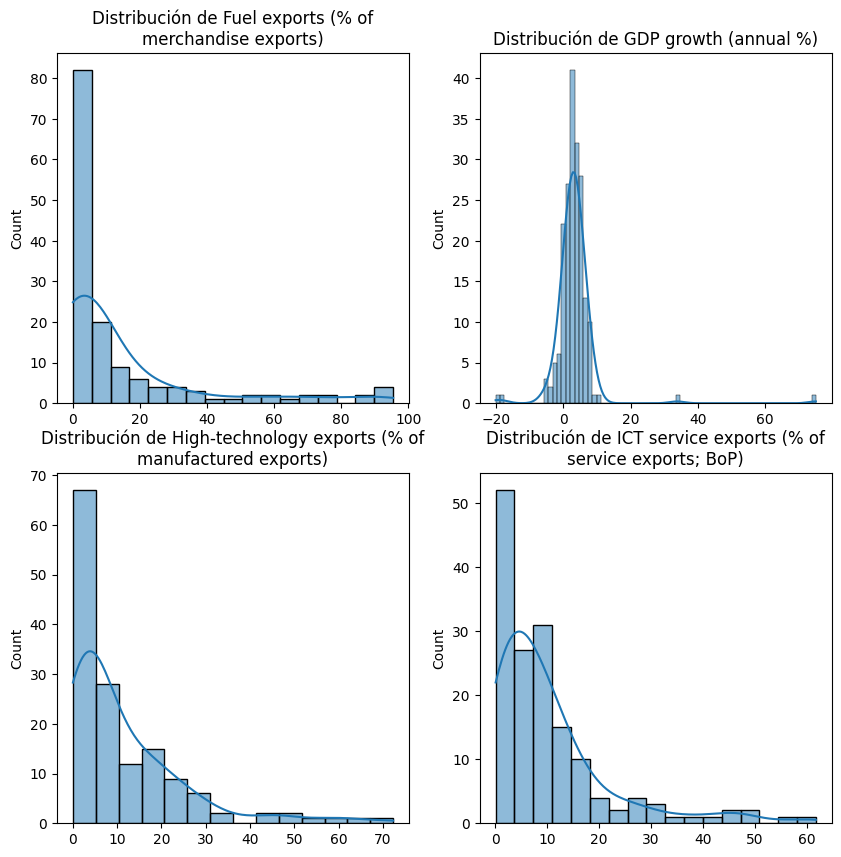

In [ ]:
# Graficar distribuciones
group2=['Fuel exports (% of merchandise exports)',
        'GDP growth (annual %)',
        'High-technology exports (% of manufactured exports)',
        'ICT service exports (% of service exports; BoP)']
# Creamos subplots, para comninar varios graficos en una sola imagen
fig, axes = plt.subplots(2,2, figsize=(10, 10))
# Creamos loop que genere histograma para cada variable
for i, var in enumerate(group2):
    row = i // 2
    col = i % 2
    sns.histplot(data_paises[var],kde=True, ax=axes[row, col])
    wrapped_title = textwrap.fill(f'Distribución de {var}', width=45)
    axes[row, col].set_title(wrapped_title)
    axes[row, col].set_xlabel('')

Podemos obserar que:

  * La variable de exportaciones de combustibles presenta una distribución extremadamente sesgada hacia la derecha, con la mayoria de paises de la muestra con porcentajes al rededor del 0%.
  * La variable de crecimiento de PBI tiene una distribución extremadamente sesgada hacia la derecha, con la mayoria de paises de la muestra con procentajes al rededor del 0% (en un rango de valores entre -20% y 80%)
  * La variable de Exportaciones altamente tecnológicas tiene una distribución fuertemente sesgada hacia la derecha, con la mayoria de paises de la muestra teniendo pporcentajes ente 0% y 5%
  * La variable de exportaciones de servicos ICT presenta una distribución fuertemente sesgada hacia la derecha, con la mayoria de paises de la muestra con porcentajes al rededor del 5%.


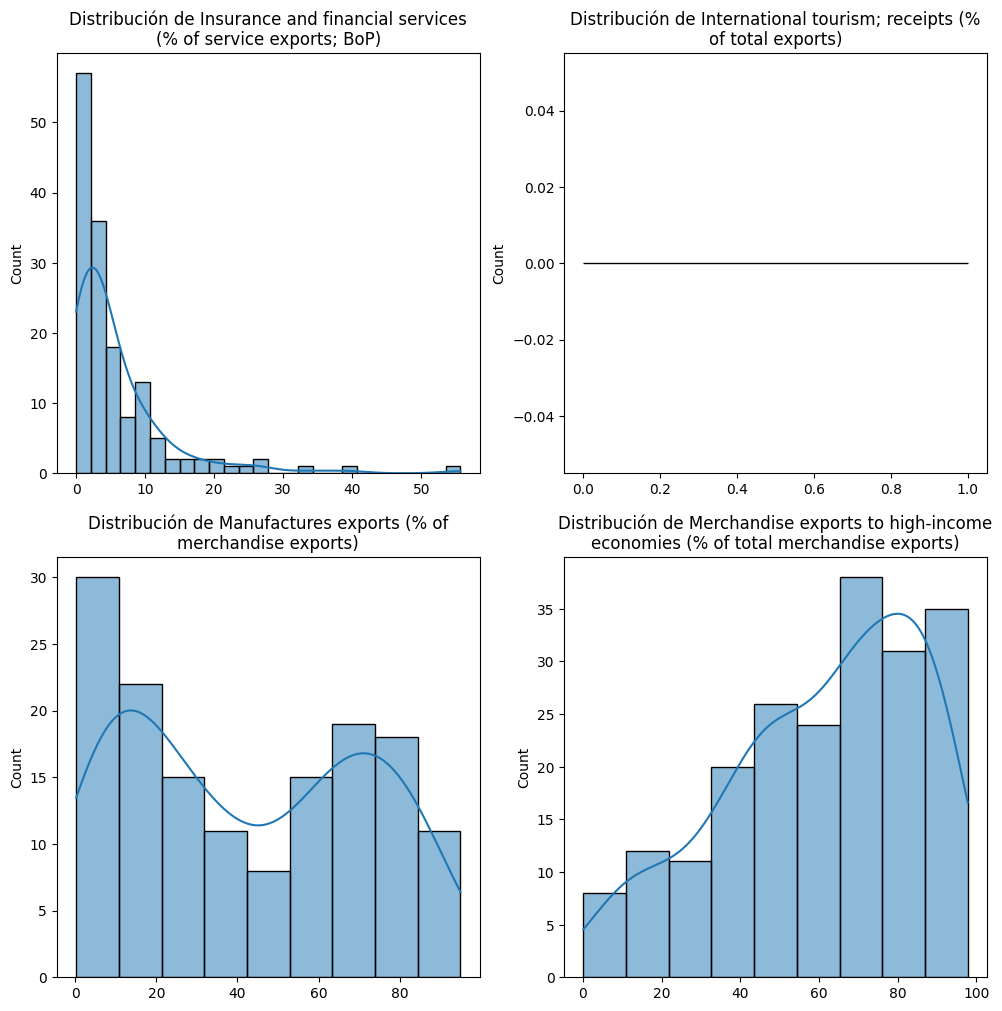

In [ ]:
# Graficar distribuciones
group3=['Insurance and financial services (% of service exports; BoP)',
        'International tourism; receipts (% of total exports)',
        'Manufactures exports (% of merchandise exports)',
        'Merchandise exports to high-income economies (% of total merchandise exports)']
# Creamos subplots, para comninar varios graficos en una sola imagen
fig, axes = plt.subplots(2,2, figsize=(12, 12))
# Creamos loop que genere histograma para cada variable
for i, var in enumerate(group3):
    row = i // 2
    col = i % 2
    sns.histplot(data_paises[var],kde=True, ax=axes[row, col])
    wrapped_title = textwrap.fill(f'Distribución de {var}', width=50)
    axes[row, col].set_title(wrapped_title)
    axes[row, col].set_xlabel('')

Podemos obserar que:

  * La variable de servicios financieros (como porcentaje de exportaciones de servicios) presenta una distribución extremadamente sesgada hacia la derecha, con la mayoria de paises de la muestra con porcentajes dentro de un rango entre 0% y 4%.
  * La variable de turismo presenta missings en todas las observaciones.
  * La variable de Exportaciones de manufacturas tiene una distribución ligeramente sesgada hacia la derecha, con dos puntos de mayor concentacion estando al rededor de 10% y 70% respectivamente.
  * La variable de exportaciones a economicas de renta alta presenta una distribución fuertemente sesgada hacia la izquierda, con la mayoria de paises de la muestra con porcentajes al rededor del 80%.

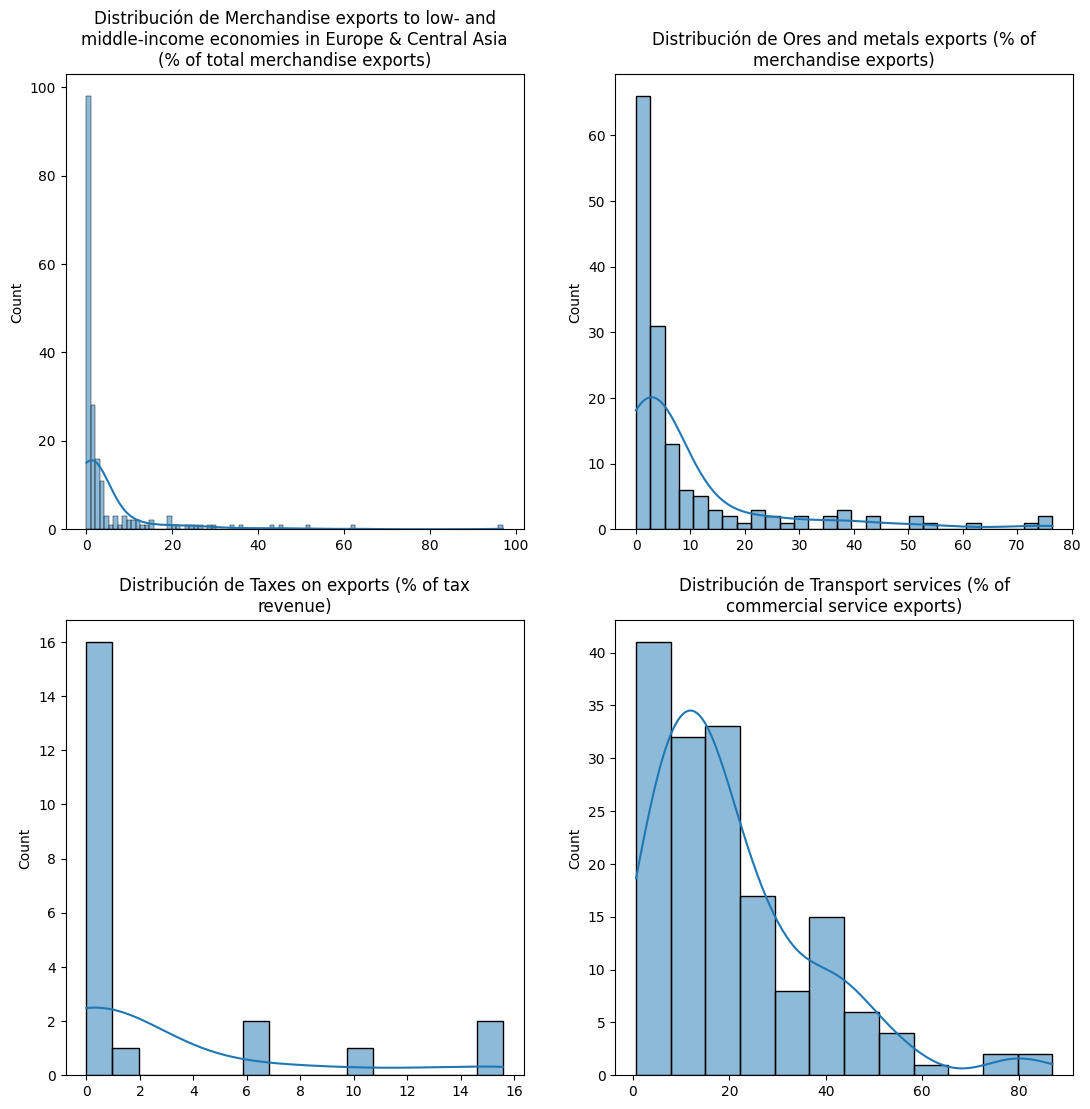

In [ ]:
# Graficar distribuciones
group4=['Merchandise exports to low- and middle-income economies in Europe & Central Asia (% of total merchandise exports)',
        'Ores and metals exports (% of merchandise exports)',
        'Taxes on exports (% of tax revenue)',
        'Transport services (% of commercial service exports)']
# Creamos subplots, para comninar varios graficos en una sola imagen
fig, axes = plt.subplots(2,2, figsize=(13, 13))
# Creamos loop que genere histograma para cada variable
for i, var in enumerate(group4):
    row = i // 2
    col = i % 2
    sns.histplot(data_paises[var],kde=True, ax=axes[row, col])
    wrapped_title = textwrap.fill(f'Distribución de {var}', width=50)
    axes[row, col].set_title(wrapped_title)
    axes[row, col].set_xlabel('')

Podemos obserar que:

  * Las variables de exportaciones a paises de renta baja, exportaciones de metales y impuestos a las exportaciones presentan distribuciones extremadamente sesgadas a la derecha, con la mayoria de paises teniendo porcentajes muy por debajo del 5%.
  * La variable de exportaciones a economicas de renta alta presenta una distribución fuertemente sesgada hacia la derecha, con la mayoria de paises de la muestra con porcentajes al rededor del 15%.

## Missing Values

### Pregunta 2.4

Realice análisis de valores vacíos y tratamiento de estos. Se premiará mantener el mayor número de observaciones posibles bajo criterios razonables. Luego de esta pregunta no deben quedar nulos en el _dataframe_ a utilizar.


In [ ]:
# Variables con Missings
missings_c = data_paises.isnull().sum()
missings_perc = (data_paises.isnull().sum() / len(data_paises)) * 100
missings = pd.DataFrame({'Núemero de Missing': missings_c, 'Porcentaje Percentage': missings_perc})
missings[missings_c > 0]
#Vemos que la mayoria de variables tienen un pocentaje missings al rededor del 20% y 30%.

,Núemero de Missing,Porcentaje Percentage
Series Name,,
Agricultural raw materials exports (% of merchandise exports),68,31.336406
Computer; communications and other services (% of commercial service exports),56,25.806452
Exports of goods and services (% of GDP),59,27.188940
Food exports (% of merchandise exports),68,31.336406
Fuel exports (% of merchandise exports),72,33.179724
GDP growth (annual %),22,10.138249
High-technology exports (% of manufactured exports),70,32.258065
ICT service exports (% of service exports; BoP),60,27.649770
Insurance and financial services (% of service exports; BoP),65,29.953917


In [ ]:
#Observamos variables con porcentajes de missings superiores al 80%, por lo que
#decidimos eliminar estas variables. No tiene sentido mantener variables que
#estarian compuestas principalmente por la mediana, ya que no habria variabilidad
#que ayude a la predicción.
limite = 0.50 * len(data_paises)
data_paises = data_paises.dropna(thresh=limite, axis=1)

In [ ]:
#Para el resto de variables decidimos imputar los missings con la mediana pues es
#la opción más robusta y recomendada para distribuciones sesgadas, ya sean a la
#izquierda o a la derecha.
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
data_imputada = pd.DataFrame(imputer.fit_transform(data_paises), columns=data_paises.columns,
                             index=data_paises.index)

In [ ]:
# Variables con Missings (observamos que no quedan missings)
missings = data_imputada.isnull().sum()
missings[missings > 0]

,0
Series Name,


## Outliers

### Pregunta 2.5

Realice análisis de datos _outliers_. De ser necesario aplique un procesamiento de outliers, de no ser necesario justifique.

Se premiará el buen criterio fundamentado.

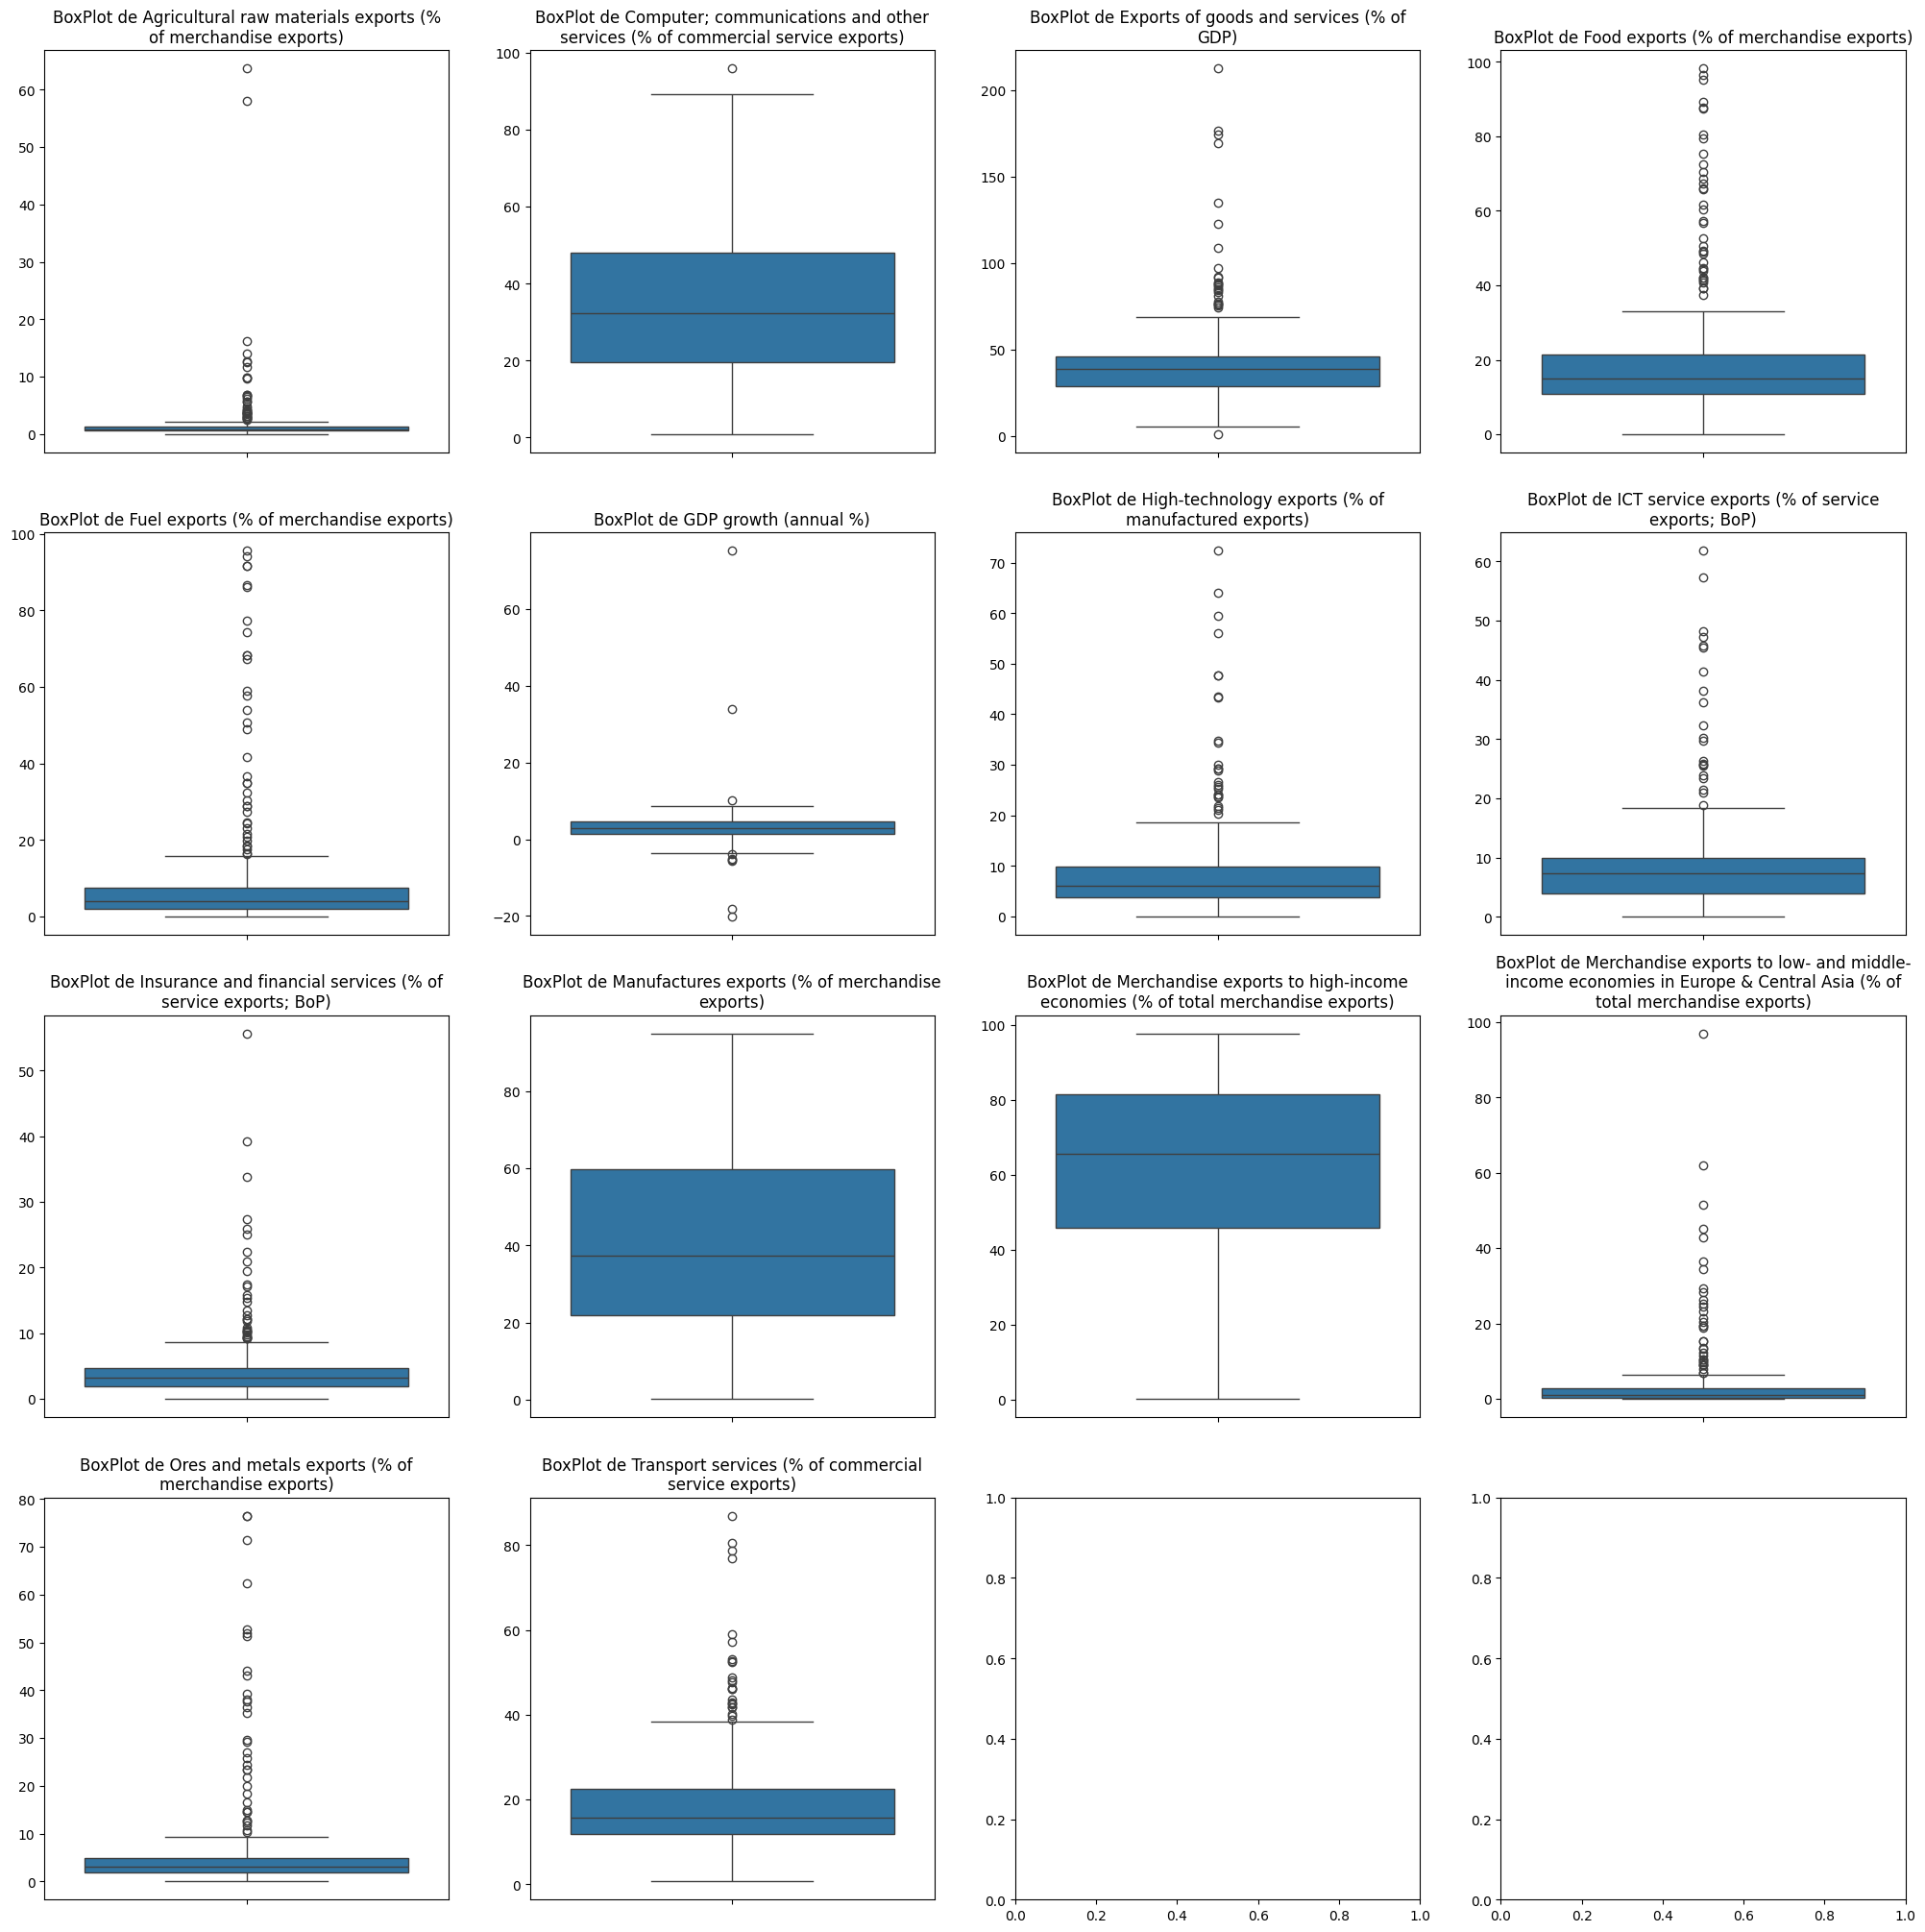

In [ ]:
# Graficar distribuciones
group11=['Agricultural raw materials exports (% of merchandise exports)',
        'Computer; communications and other services (% of commercial service exports)',
        'Exports of goods and services (% of GDP)',
        'Food exports (% of merchandise exports)','Fuel exports (% of merchandise exports)',
        'GDP growth (annual %)',
        'High-technology exports (% of manufactured exports)',
        'ICT service exports (% of service exports; BoP)',
        'Insurance and financial services (% of service exports; BoP)',
        'Manufactures exports (% of merchandise exports)',
        'Merchandise exports to high-income economies (% of total merchandise exports)',
         'Merchandise exports to low- and middle-income economies in Europe & Central Asia (% of total merchandise exports)',
        'Ores and metals exports (% of merchandise exports)',
        'Transport services (% of commercial service exports)']
# Creamos subplots, para comninar varios graficos en una sola imagen
fig, axes = plt.subplots(4,4, figsize=(25, 25))
# Creamos loop que genere histograma para cada variable
for i, var in enumerate(group11):
    row = i // 4
    col = i % 4
    sns.boxplot(data_imputada[var], ax=axes[row, col])
    wrapped_title = textwrap.fill(f'BoxPlot de {var}', width=50)
    axes[row, col].set_title(wrapped_title)
    axes[row, col].set_ylabel('')

Porcentajes de exportación inusualmente altos o bajos para un país no son necesariamente un error de la base o un dato atípico, es una realidad económica. Quizás ese país es un gigante en exportación un solo tipo de producto (como los paises petroleros), o tuvo un buen año para las exportaciones (por diferentes contextos como guerras, bloqueos económicos, etc). Si imputaramos estas variables, reemplazando outliers con media o mediana, se perderia información valiosa sobre la especialización de un país o eventos económicos clave. Si un país exporta el 80% de un producto, eso es un dato, no un error que deba "normalizarse" al 30% del promedio. Al cambiarlo, perdemos variabilidad y representabilidad de la realidad económica. Estos outliers son información, no ruido. Respetar su existencia nos dará una imagen mucho más fiel y útil de la economía global. Si nos molesta la distribución asimétrica, se podria realizar una transformación logaritmica para que las distribuciones se asemejen a una normal; sin embargo, considerando que ni K-means ni PCA asumen distribuciones normales, veemos este paso innnecesario.

## Feature Engineering


### Pregunta 2.6

Realice _feature engineering_ de las variables numéricas (para luego entrenar un modelo _K-Means_ con estas). Realice los ajustes que estime conveniente, pero su tratamiento debe incluir por lo menos estandarización de las variables.

Más adelante se le pedirá comentar sobre los resultados de sus modelos, por lo que considere que sus decisiones podrían condicionar futuras preguntas.



In [ ]:
#Realizamos la estandarización de las variables
from sklearn.preprocessing import StandardScaler, Normalizer
scaler = StandardScaler()
data_fe = scaler.fit_transform(data_imputada)
data_scl = pd.DataFrame(data_fe, columns=data_imputada.columns, index=data_imputada.index)
data_scl.head()

Series Name,Agricultural raw materials exports (% of merchandise exports),Computer; communications and other services (% of commercial service exports),Exports of goods and services (% of GDP),Food exports (% of merchandise exports),Fuel exports (% of merchandise exports),GDP growth (annual %),High-technology exports (% of manufactured exports),ICT service exports (% of service exports; BoP),Insurance and financial services (% of service exports; BoP),Manufactures exports (% of merchandise exports),Merchandise exports to high-income economies (% of total merchandise exports),Merchandise exports to low- and middle-income economies in Europe & Central Asia (% of total merchandise exports),Ores and metals exports (% of merchandise exports),Transport services (% of commercial service exports)
Country Name,,,,,,,,,,,,,,
Afghanistan,-0.214235,-0.100056,-0.941195,-0.309384,-0.348602,-0.079903,-0.317476,-0.216198,-0.271324,-0.137254,-1.992231,0.460805,-0.331966,-0.245495
Albania,-0.277068,-0.487227,-0.173209,-0.462840,-0.233398,0.115280,-0.788481,-0.648981,-0.660427,0.661229,0.681849,1.355544,-0.163316,-0.574067
Algeria,-0.214235,1.227298,-0.701067,-0.309384,-0.348602,0.141296,-0.317476,-0.730132,0.812851,-0.137254,0.783811,0.159162,-0.331966,0.419233
American Samoa,-0.214235,-0.100056,-0.168814,-0.309384,-0.348602,-0.040206,-0.317476,-0.216198,-0.271324,-0.137254,0.494068,-0.352074,-0.331966,-0.245495
Andorra,-0.275557,-1.057325,-0.168814,-1.002453,-0.558127,-0.100180,1.038994,-0.513710,-0.190945,2.243791,0.185804,-0.334430,-0.436031,-1.207533


## K-Means

### Pregunta 2.7

Considerando el dataframe completo (todas sus columnas atributos), determine el número óptimo de clusters mediante el "Elbow method". Considere un rango $k \in [1, 30]$. Describa el comportamiento observado de la curva.



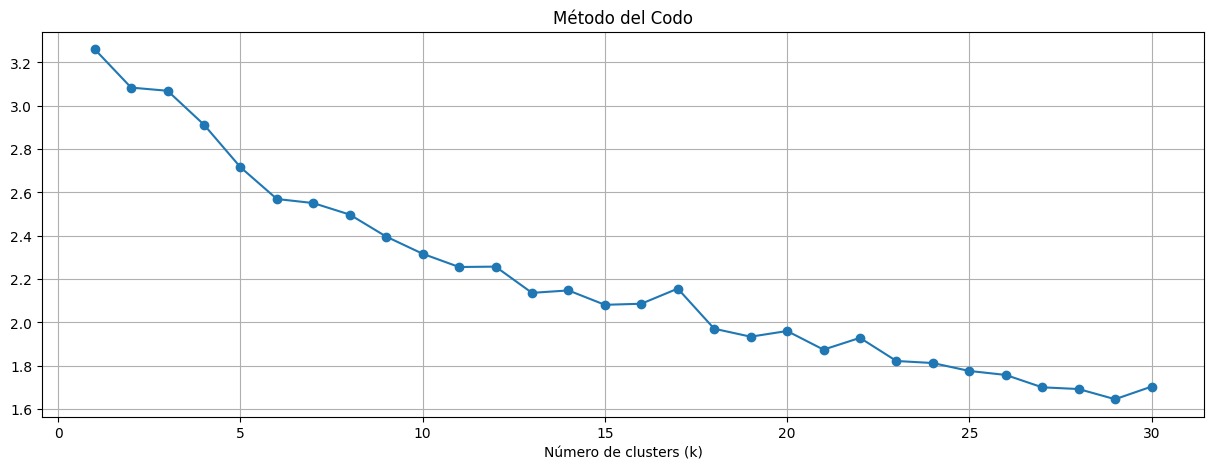

In [ ]:
# Calcular inercia para diferentes k
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
dispersion = []
for k in range(1, 31):
    kmeans = KMeans(n_clusters=k, )
    kmeans.fit(data_scl)
    dist_euclid = cdist(data_scl, kmeans.cluster_centers_, 'euclidean')
    min_dist = np.min(dist_euclid, axis=1)
    prom_dist= sum(min_dist) / len(data_fe)
    dispersion.append(prom_dist)

# Graficar elbow method
fig = plt.figure(figsize=(15, 5))
plt.plot(range(1, 31), dispersion, marker='o')
plt.xlabel('Número de clusters (k)')
plt.title('Método del Codo')
plt.grid(True)

 En el metodo del codo, buscamos un punto donde la curva se "dobla" bruscamente, como un codo, lo que represetaria un punto de inflexión donde la ganancia marginal de añadir un cluster adicional empieza a disminuir drásticamente En este caso, el codo parece estar alrededor de k=5 o k=6, indicando que añadir más clusters después de este punto no reduce significativamente la inercia, sugiriendo un número óptimo de agrupaciones. Debemos tomar en cuenta que este método es sensible a alta dimensionalidad, es decir, pierde rendimiento con una mayor cantidad de variables (14 en este caso). Por esto, quizas el número de clusters indicado no sea el realmente optimo.



### Pregunta 2.8

Un problema habitual del modelo _K-Means_ es que pierde desempeño a mayor dimensionalidad.

En esta pregunta defina **por lo menos 5 combinaciones de columnas** (mínimo 2 columnas y máximo 4). Para cada combinación determine el número óptimo de clusters mediante el "Elbow method" considerando $k \in [1, 30]$.

Un posible enfoque para lo anterior es tomar un _approach_ estadístico y escoger variables que empíricamente muestran mayores indicios de poder diferenciador entre las observaciones. De todas formas, recuerde que la pregunta de interés es "¿qué países se verán expuestos de forma similar a la guerra comercial?". En este sentido, es altamente recomendable escoger variables con una mayor relación al fenómeno de la guerra comercial, ya que puede ser útil para discernir de qué forma podría verse expuesto cada grupo.


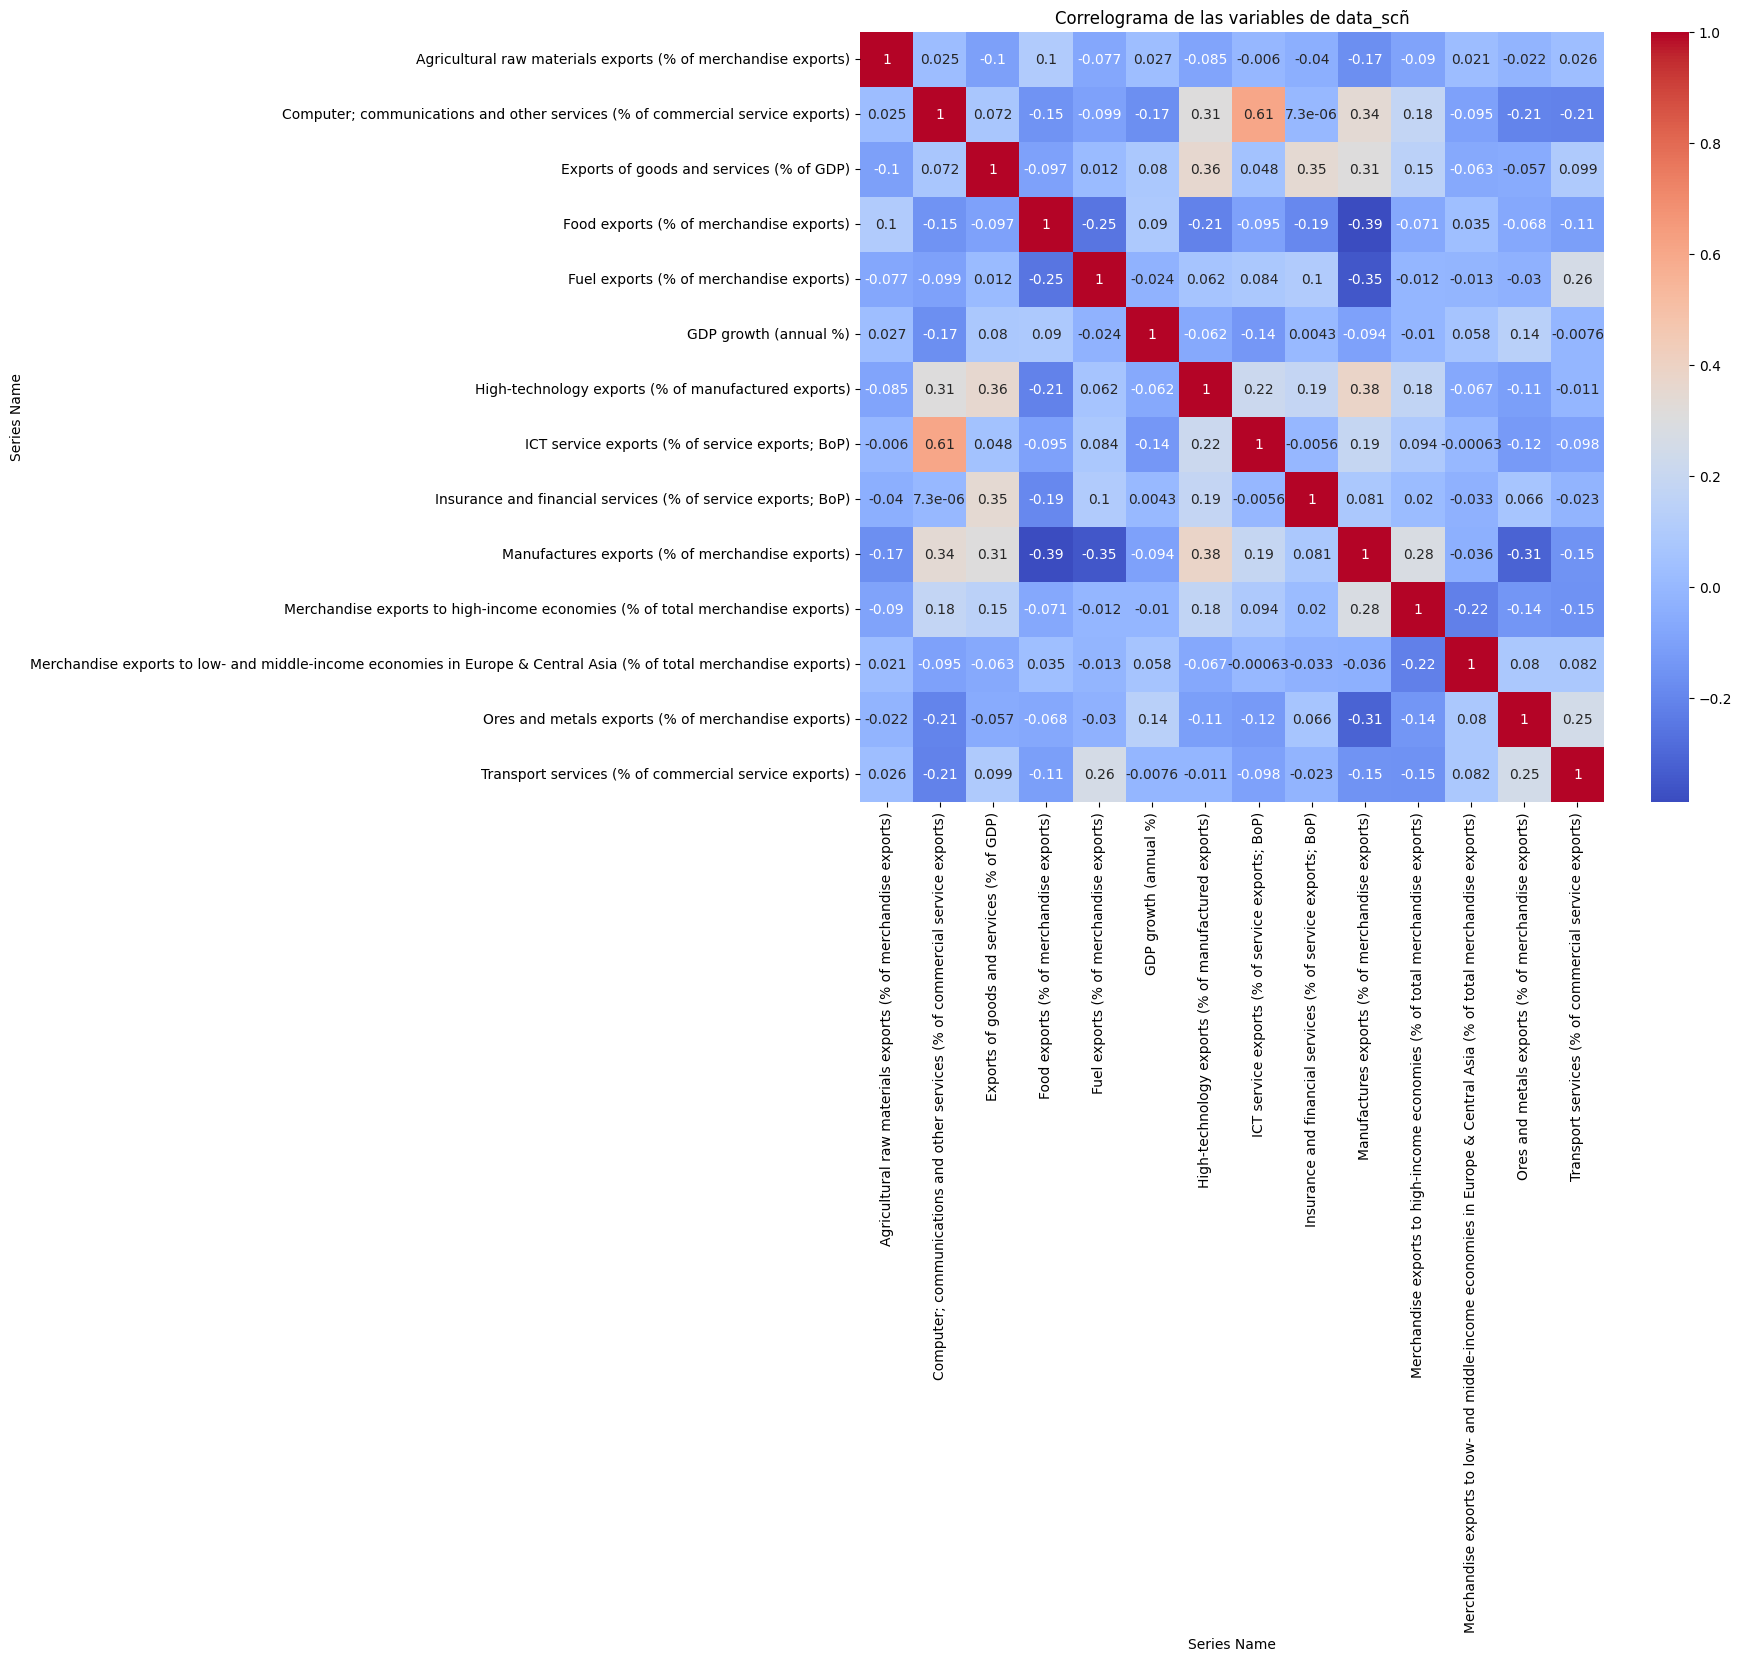

In [ ]:
#Observamos correlaciones de variables para crear diferentes combinaciones
data_corr = data_scl.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(data_corr, cmap='coolwarm', annot=True)
plt.title('Correlograma de las variables de data_scñ')
plt.show()

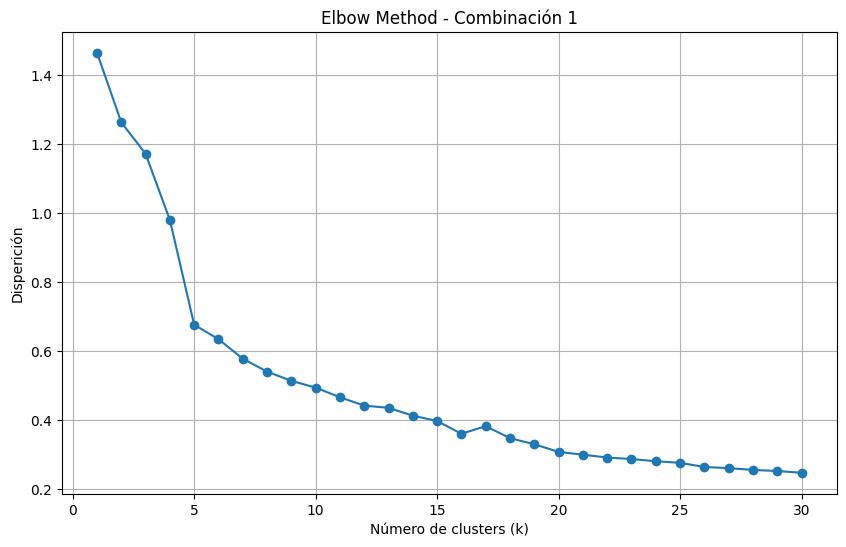

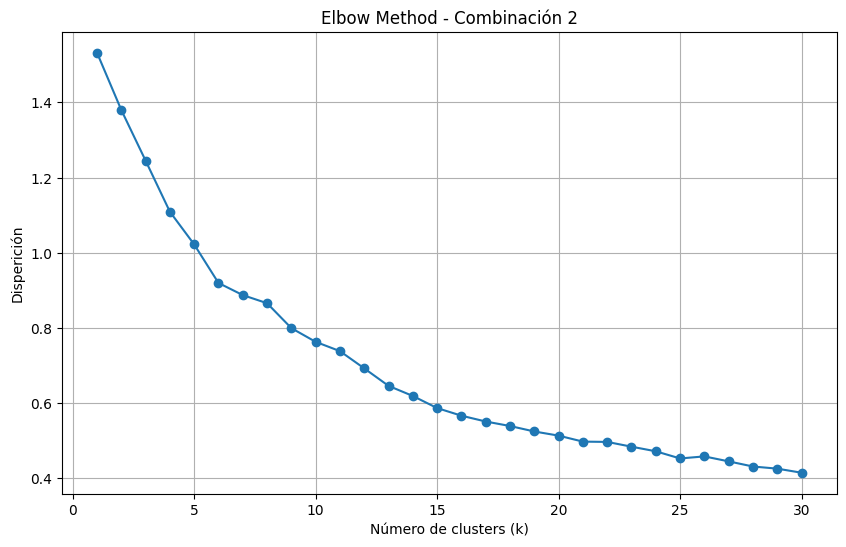

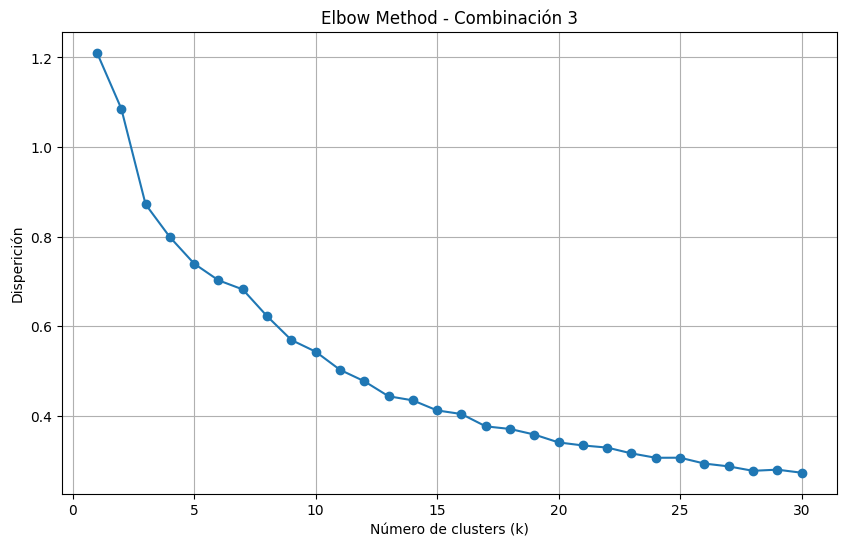

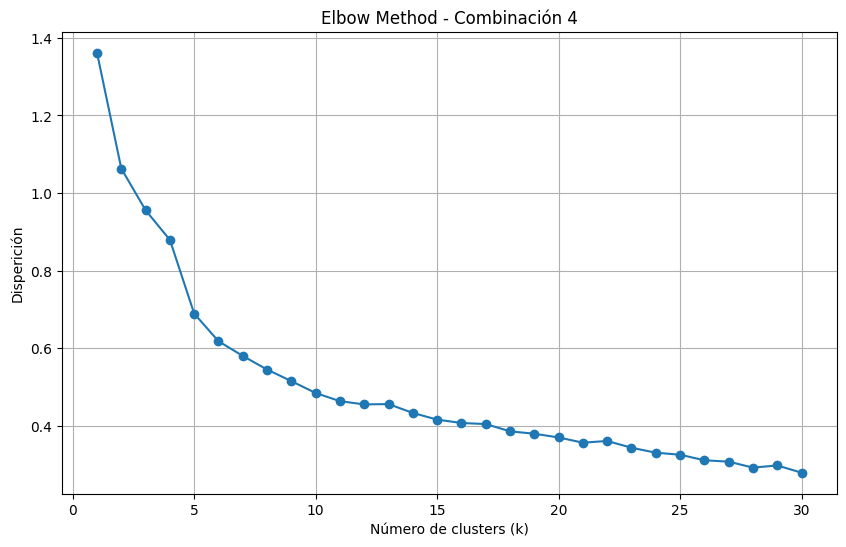

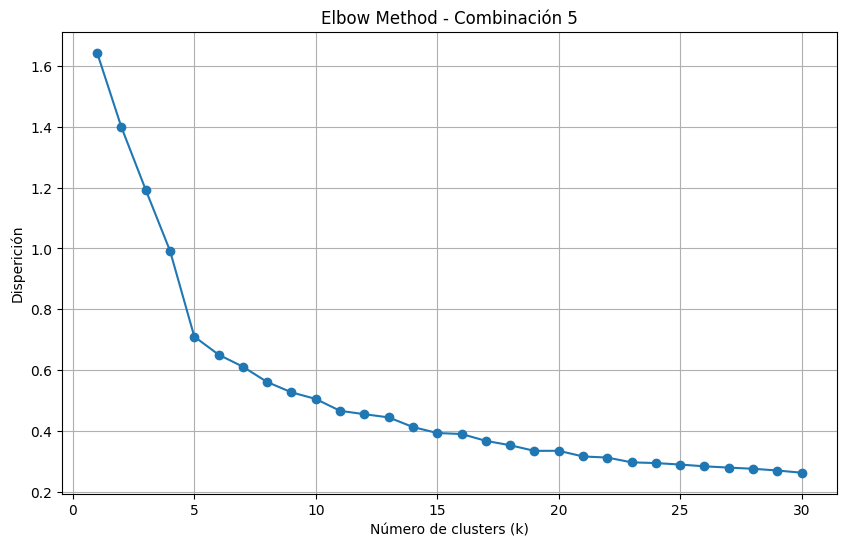

In [ ]:
# En base a lo anterior y a la intuición económica, definimos combinaciones que
# representen las principales correlaciones o que represeten la mayoria
# de tipos de exportaciones que tienen los paises.
combinaciones = [['Agricultural raw materials exports (% of merchandise exports)',
              'Food exports (% of merchandise exports)',
              'Ores and metals exports (% of merchandise exports)',
              'Fuel exports (% of merchandise exports)'],
              ['GDP growth (annual %)',
              'Exports of goods and services (% of GDP)',
              'Merchandise exports to high-income economies (% of total merchandise exports)',
              'Merchandise exports to low- and middle-income economies in Europe & Central Asia (% of total merchandise exports)',],
              ['Insurance and financial services (% of service exports; BoP)',
              'Transport services (% of commercial service exports)',
               'GDP growth (annual %)'],
              ['Computer; communications and other services (% of commercial service exports)',
              'ICT service exports (% of service exports; BoP)',
               'High-technology exports (% of manufactured exports)'],
              ['Food exports (% of merchandise exports)',
              'Manufactures exports (% of merchandise exports)',
              'Ores and metals exports (% of merchandise exports)',
              'Fuel exports (% of merchandise exports)']]

# Evaluar cada combinación
for i, comb in enumerate(combinaciones, 1):
    subset = data_scl[comb]

    dispercion = []
    for k in range(1, 31):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(subset)
        # Calculate distances using the subset
        dist_euclid = cdist(subset, kmeans.cluster_centers_, 'euclidean')
        min_dist = np.min(dist_euclid, axis=1)
        prom_dist= sum(min_dist) / len(subset) # Calculate average distance for the subset
        dispercion.append(prom_dist)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, 31), dispercion, marker='o')
    plt.xlabel('Número de clusters (k)')
    plt.ylabel('Disperición')
    plt.title(f'Elbow Method - Combinación {i}')
    plt.grid()
    plt.show()

Se generaron combinaciones de variables agrupan indicadores económicos clave, buscando capturar los principales aspectos de las exportaciones y el crecimiento de los países.

Las primeras dos listas se enfocan en exportaciones de bienes por tipo de producto y destinos económicos, junto con el crecimiento del PIB. Las siguientes dos exploran las exportaciones de servicios (tradicionales y de alta tecnología). Finalmente, la última combina varios tipos de exportaciones de mercancías que buscan representar la mayoria de bienes expotados por los paises.

El objetivo es representar tanto las correlaciones dominantes como la diversidad de estructuras exportadoras que un país puede tener, cubriendo bienes, servicios, tecnología y materias primas.

### Pregunta 2.9

Escoja la combinación de columnas que considera adecuada emplear, refiriéndose tanto al comportamiento observado de la curva, como al nivel de la métrica empleada al que se alcanza la convergencia.

Estime el modelo con $k$ óptimo y las columnas escogidas. Visualice los grupos graficando _scatterplots_. Considere gráficos en 3 dimensiones si su modelo posee 3 o más variables.

Describa en qué se diferencian los grupos encontrados y de qué manera le podría afectar la guerra comercial a cada uno. Liste una pequeña muestra representativa de los países que contiene cada grupo.


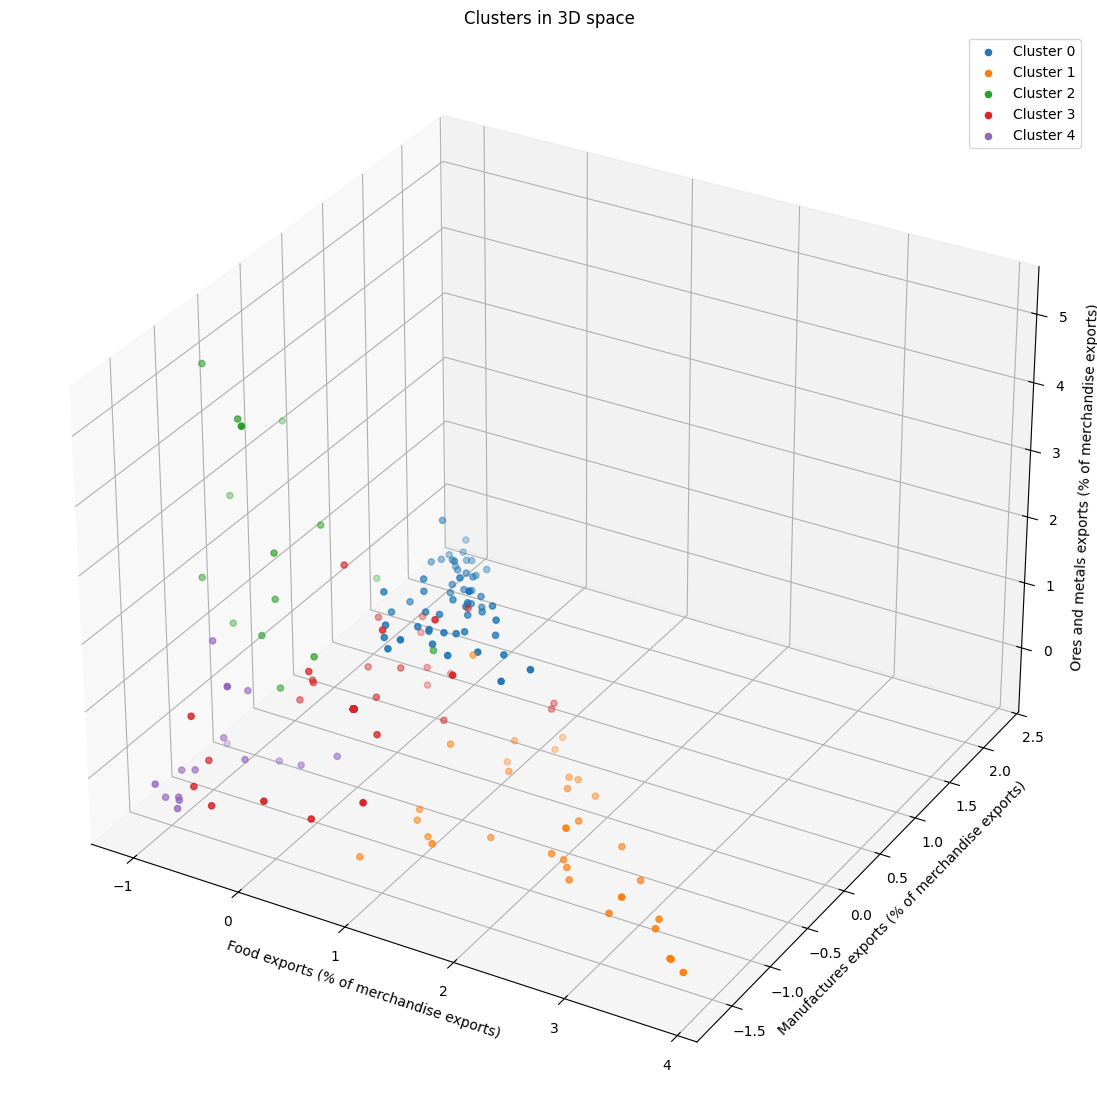


Cluster 0:
['Albania', 'Andorra', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Botswana', 'Cambodia', 'China', 'Costa Rica', 'Croatia', 'Czechia', 'Denmark', 'Dominican Republic', 'El Salvador', 'Estonia', 'Eswatini', 'Finland', 'France', 'French Polynesia', 'Germany', 'Hong Kong', 'Hungary', 'India', 'Ireland', 'Israel', 'Italy', 'Japan', 'Jordan', 'Korea Rep.', 'Lesotho', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta', 'Mexico', 'Morocco', 'Netherlands', 'North Macedonia', 'Pakistan', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Singapore', 'Slovak Republic', 'Slovenia', 'Spain', 'Sri Lanka', 'Sweden', 'Switzerland', 'Thailand', 'Trinidad and Tobago', 'Tunisia', 'Turkiye', 'United Kingdom', 'United States', 'West Bank and Gaza']

Cluster 1:
['Antigua and Barbuda', 'Argentina', 'Aruba', 'Bahamas', 'Barbados', 'Belize', 'Benin', 'Brazil', 'Cabo Verde', "Cote d'Ivoire", 'Ecuador', 'Ethiopia', 'Fiji', 'Gambia', 'Grenada', 'Guatemala', 'Honduras', 'Kenya', 'Malawi', 'Maldives', '

,Food exports (% of merchandise exports),Manufactures exports (% of merchandise exports),Ores and metals exports (% of merchandise exports),Fuel exports (% of merchandise exports)
0,-0.497510,1.396574,-0.327740,-0.261138
1,2.079719,-0.839554,-0.265908,-0.319104
2,-0.162533,-1.176945,3.220531,-0.109890
3,-0.242885,-0.166597,-0.195529,-0.251047
4,-0.762191,-1.182809,-0.134465,3.193507


In [ ]:
# Elegir la combinación 5, que busca representar las principales exportaciones
# de la mayoria de paises.
comb_5 = ['Food exports (% of merchandise exports)',
          'Manufactures exports (% of merchandise exports)',
          'Ores and metals exports (% of merchandise exports)',
          'Fuel exports (% of merchandise exports)']

subset = data_scl[comb_5]

# k óptimo parece ser 5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42,n_init=10)
clusters = kmeans.fit_predict(subset)

# Añadir clusters al dataframe
data_scl['Cluster'] = clusters

# Visualización 3D (hay 4 variables)
if len(comb_5) == 4:
    fig = plt.figure(figsize=(14, 14))
    ax = fig.add_subplot(111, projection='3d')

    for cluster in range(optimal_k):
        cluster_data = subset[clusters == cluster]

        ax.scatter(cluster_data[comb_5[0]],
                  cluster_data[comb_5[1]],
                  cluster_data[comb_5[2]],
                  label=f'Cluster {cluster}')

    ax.set_xlabel(comb_5[0])
    ax.set_ylabel(comb_5[1])
    ax.set_zlabel(comb_5[2])
    plt.title('Clusters in 3D space')
    plt.legend()
    plt.show()

# Mostrar países por cluster
for cluster in range(optimal_k):
    print(f"\nCluster {cluster}:")
    print(data_scl[data_scl['Cluster'] == cluster].index.tolist()[:200])  # Mostrar primeros 10

# Analizar centroides
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=comb_5)
print("\nCentroides:")
display(centroids)

Los clústeres identificados, basados en sus centroides de variables de exportación, revelan perfiles económicos distintivos con implicaciones variadas frente a una guerra comercial:

* Cluster 0 (Economías Manufactureras y de Alta Tecnología): Caracterizado por una prominencia significativa en exportaciones de manufacturas (centroide: 1.38). Estos países, altamente integrados en cadenas de valor globales, son intrínsecamente vulnerables a conflictos comerciales que impongan aranceles o barreras no arancelarias a bienes industriales o que disrumpan la logística global, afectando su producción y competitividad. Ejemplos: Alemania, China,Francia, India, Estados Unidos.

* Cluster 1 (Economías Agrícolas): Definido por una marcada especialización en exportaciones de alimentos (centroide: 2.07). Su exposición a una guerra comercial radica en la posible imposición de aranceles a productos agrícolas clave o en una contracción de la demanda global, lo que podría generar una disminución sustancial en sus ingresos por exportaciones y afectar su balanza comercial. Ejemplos: Argentina, Brasil, Uruguay, Nueva Zelanda.

* Cluster 2 (Economías Extractivas de Minerales): Evidencia una extrema dependencia de exportaciones de minerales y metales (centroide: 3.22). Su vulnerabilidad es directa ante fluctuaciones en la demanda global de commodities o políticas arancelarias dirigidas a estos recursos, lo que impactaría severamente sus economías rentistas. Ejemplos: Australia, Bolivia, Chile, Perú.

* Cluster 3 (Economías Diversificadas, Promedio o muy pequeñas): Presenta valores para todas las variables de exportación de bienes cercanos al promedio global (centroides alrededor de -0.2). Este grupo heterogéneo exhibe una menor especialización en las categorías analizadas, lo que podría conferirles cierta resiliencia. No obstante, una desaceleración económica global inducida por una guerra comercial aún podría impactar negativamente su comercio general, aunque de forma menos focalizada. Este cluster puede ser resultado de la no inclusión de otras variables de exportación relevantes (debido a la limitación de 4 variables como máximo por com Ejemplos: Canadá, Grecia, Indonesia. Aunque en este cluster, se observan algunos ejemplos raros como Rusia y Arabia Saudita, que son paises con una matriz exportadora de principalmente combustibles. Esto puede ser resultado de la imputación de Missings con la mediana, o que elimina la singularidad de la obseración. Por ejemplo, este es el caso para Arabia Saudita, cuyas exportaciones de petroleo eran missing y fueron imputadas con la mediana.

* Cluster 4 (Economías Exportadoras de Combustibles): Se caracteriza por una abrumadora dependencia de las exportaciones de combustibles (centroide: 3.19). La susceptibilidad de estos países a una guerra comercial se materializa a través de caídas en los precios internacionales de la energía o la imposición de sanciones que restrinjan sus mercados. Ejemplos: Emiratos Arabes, Qatar, Noruega, Nigeria.

En síntesis, la severidad del impacto de una guerra comercial es directamente proporcional al grado de especialización exportadora de cada clúster.

## PCA

_PCA_ es una técnica de reducción de dimensionalidad que nos permite trabajar sobre un set de componentes principales ortogonales (mayor facilidad para los modelos a la hora de detectar patrones), además de permitirnos visualizar espacios multidimensionales, quedándonos sobre el espacio de PCA.



### Pregunta 2.10

Utilizando todas las variables originales y $k$ óptimo escogido en la pregunta anterior, estime un PCA con 2 componentes principales. Luego, estime un modelo _K-Means_ sobre los componentes principales obtenidos. Grafique las observaciones en un _scatterplot_ de 2 dimensiones. Coloree los puntos usando los label de los clusters obtenidos.

¿Cuáles son las principales diferencias entre los grupos? Encuentre las variables más definitivas a la hora de agrupar países con los 2 primeros componentes principales.


In [ ]:
from sklearn.decomposition import PCA
data_scl = data_scl.drop('Cluster', axis=1)
#Numero de PCAs = 2
pca = PCA(n_components=2)
dfscl_pca = pca.fit_transform(data_scl)
var_exp = pca.explained_variance_ratio_
print(var_exp)
print('El total de la varianza explicada por PCA: ',round(sum(var_exp),4)*100,'%')

[0.19144613 0.12326732]
El total de la varianza explicada por PCA:  31.47 %


In [ ]:
model = KMeans(n_clusters=5)
#Entrenamos
model.fit(dfscl_pca)

KMeans(n_clusters=5)

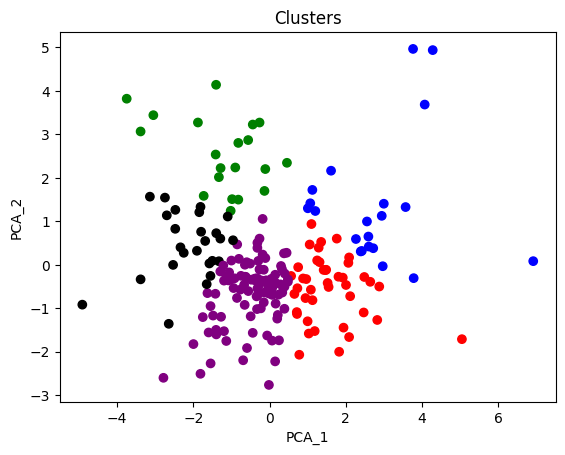

In [ ]:
# Realicemos un scatter plot de los datos coloreando los clusters
colors = ['red', 'purple', 'green', 'blue','black']
point_colors = [colors[label] for label in model.labels_]
plt.scatter(dfscl_pca[:, 0], dfscl_pca[:, 1],c=point_colors)
plt.title('Clusters')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
plt.show()

In [ ]:
# Variables más importantes en los componentes
pca_loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=data_scl.columns)
print("Variables más importantes en PC1:")
print(pca_loadings['PC1'].abs().sort_values(ascending=False).head(5))
print("\nVariables más importantes en PC2:")
print(pca_loadings['PC2'].abs().sort_values(ascending=False).head(5))

Variables más importantes en PC1:
Series Name
Manufactures exports (% of merchandise exports)                                  0.460550
Computer; communications and other services (% of commercial service exports)    0.417337
High-technology exports (% of manufactured exports)                              0.386465
ICT service exports (% of service exports; BoP)                                  0.325037
Merchandise exports to high-income economies (% of total merchandise exports)    0.274908
Name: PC1, dtype: float64

Variables más importantes en PC2:
Series Name
Transport services (% of commercial service exports)            0.422306
Insurance and financial services (% of service exports; BoP)    0.399328
Fuel exports (% of merchandise exports)                         0.390637
Exports of goods and services (% of GDP)                        0.367648
Food exports (% of merchandise exports)                         0.365136
Name: PC2, dtype: float64


La visualización de los clústeres en el grafico de scatterplot PCA  y los pesos de las variables en cada componente nos permiten interpretar las diferencias de los principales componentes:
* PC1 (Componente Principal 1): Esta componente está fuertemente correlacionada positivamente con variables que representan una econompia con industrialización(manufactura), tecnología (computación, tecnologia alta y ICT) y orientación hacia mercados de alto valor agregado.

* PC2 (Componente Principal 2): Esta componente tiene variables que capturaran aspectos de dependencia de servicios más tradicionales como transporte, seguros y  de recursos primarios (combustibles, alimentos).

Considerando la distribución de los cluters en el gráfico de PCA:

* Clúster 0 (Azul): Posicionado con valores altos en PC1, lo que indica una fuerte presencia en manufacturas y servicios de alta tecnología. Son economías altamente industrializadas y tecnológicamente avanzadas, con comercio hacia economías de altos ingresos. Este clúster se agrupa en la parte superior-izquierda del gráfico de PCA, reflejando su alto PC1 y valores variables en PC2.

* Cluster 1 (Rojo): Tiende a tener valores bajos en PC1 y variables en PC2. Sus centroides muestran una marcada especialización en exportaciones de alimentos. En el gráfico, ocupa la parte central-inferior, lo que sugiere una menor sofisticación tecnológica en sus exportaciones y un perfil más agrario.

* Cluster 2 (Verde): Muestra valores bajos en PC1 y puede variar en PC2, destacando por sus exportaciones de minerales y metales. En la visualización, se extiende hacia la derecha y parte inferior, indicando una baja sofisticación manufacturera pero una particular dependencia de recursos primarios que podría influir en el PC2.

* Cluster 3 (Negro): Concentrado alrededor del origen del gráfico de PCA (0,0), lo que sugiere que sus variables tienen valores cercanos al promedio global en ambos componentes principales. Es un grupo heterogéneo que no exhibe una especialización marcada en las dimensiones capturadas por PC1 y PC2.

* Cluster 4 (Morado): Con un valor elevado en PC2 y un rango variable en PC1, caracterizándose principalmente por sus exportaciones de combustibles. Este clúster se ubica en la parte superior-derecha de la visualización, reflejando su fuerte contribución al componente 2 por las exportaciones de combustibles.

### Pregunta 2.11


Repita lo anterior  (descripción incluida), pero con 3 componentes principales y un _scatterplot_ en 3 dimensiones.

In [ ]:
pca3 = PCA(n_components=3)
dfscl_pca_2 = pca3.fit_transform(data_scl)
var_exp = pca3.explained_variance_ratio_
print(var_exp)
print('El total de la varianza explicada por PCA: ',round(sum(var_exp),4)*100,'%')

[0.19144613 0.12326732 0.09929328]
El total de la varianza explicada por PCA:  41.4 %


In [ ]:
model3 = KMeans(n_clusters=5)
#Entrenamos
model3.fit(dfscl_pca_2)

KMeans(n_clusters=5)

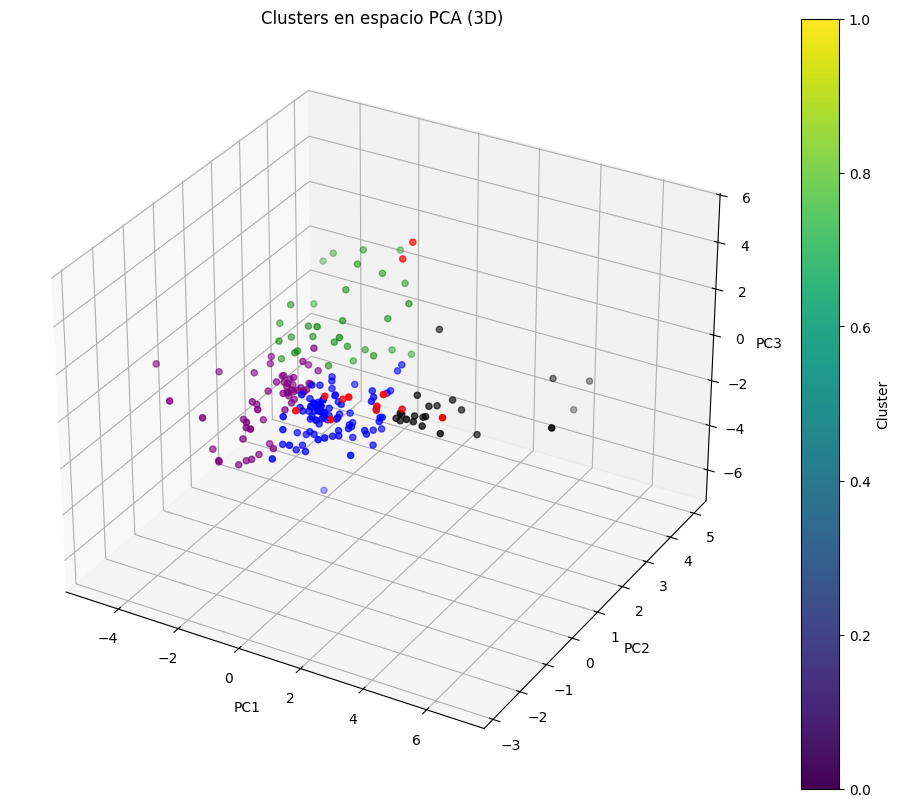

In [ ]:
# Realicemos un scatter plot de los datos coloreando los clusters
colors = ['red', 'purple', 'green', 'blue','black']
point_colors = [colors[label] for label in model3.labels_]

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(dfscl_pca_2[:, 0], dfscl_pca_2[:, 1], dfscl_pca_2[:, 2],
                    c=point_colors, cmap='viridis')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('Clusters en espacio PCA (3D)')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [ ]:
# Variables más importantes en los componentes
pca_loadings2 = pd.DataFrame(pca3.components_.T, columns=['PC1', 'PC2', 'PC3'], index=data_scl.columns)
print("Variables más importantes en PC1:")
print(pca_loadings2['PC1'].abs().sort_values(ascending=False).head(5))
print("\nVariables más importantes en PC2:")
print(pca_loadings2['PC2'].abs().sort_values(ascending=False).head(5))
print("\nVariables más importantes en PC3:")
print(pca_loadings2['PC3'].abs().sort_values(ascending=False).head(5))

Variables más importantes en PC1:
Series Name
Manufactures exports (% of merchandise exports)                                  0.460550
Computer; communications and other services (% of commercial service exports)    0.417337
High-technology exports (% of manufactured exports)                              0.386465
ICT service exports (% of service exports; BoP)                                  0.325037
Merchandise exports to high-income economies (% of total merchandise exports)    0.274908
Name: PC1, dtype: float64

Variables más importantes en PC2:
Series Name
Transport services (% of commercial service exports)            0.422306
Insurance and financial services (% of service exports; BoP)    0.399328
Fuel exports (% of merchandise exports)                         0.390637
Exports of goods and services (% of GDP)                        0.367648
Food exports (% of merchandise exports)                         0.365136
Name: PC2, dtype: float64

Variables más importantes en PC3:
Serie

Los resultados revelan revelan las dimensiones subyacentes que diferencian a los grupos de países, lo cual es clave para entender las variaciones en sus estructuras económicas.

* El Componente Principal 1 (PC1) se define por la sofisticación económica y la orientación hacia la manufactura y servicios avanzados. Variables como la exportación de manufacturas (0.46), servicios de informática y comunicación (0.41), y tecnología punta (0.38) dominan esta dimensión. Los países con altos valores en PC1 son economías industrializadas y tecnológicamente avanzadas.

* El Componente Principal 2 (PC2) refleja una combinación de dependencia de recursos primarios y servicios de soporte comercial. Las exportaciones de transporte (0.42), servicios financieros (0.39), combustibles (0.39) y alimentos (0.36), junto con la apertura comercial (% del PIB), lo caracterizan. Este PC distingue entre economías que dependen de materias primas o de sectores de servicios logísticos y financieros.

* Finalmente, el Componente Principal 3 (PC3) captura el dinamismo de crecimiento y el peso de las TIC y combustibles. Cargas importantes en exportaciones TIC (0.47), combustibles (0.46) y el crecimiento del PIB (0.34) lo definen. Este PC es crucial para identificar economías con un crecimiento robusto, a menudo ligado a energía o servicios digitales.

* Las principales diferencias entre los grupos de países, como se visualiza en el espacio PCA, surgen de su posición a lo largo de estos tres ejes, reflejando su grado de industrialización/tecnología, su base de recursos/servicios tradicionales y su dinamismo económico. Las variables con mayores pesos en cada PC son, por ende, las más definitorias de estas agrupaciones.

### Pregunta 2.12

Otro de los usos de los más comúnes de _PCA_, además de _feature engineering_, es la visualización. En esta sección utilizaremos _PCA_ para confirmar visualmente que estamos clusterizando países similares.

Usando el diccionario en la celda de abajo agrega una columna de continente al _dataframe_ de trabajo.

In [ ]:
country_continent_mapping = {
    'Albania': 'Europe',
    'Argentina': 'South America',
    'Armenia': 'Asia',
    'Aruba': 'North America', # Usually classified with the Caribbean
    'Australia': 'Oceania',
    'Austria': 'Europe',
    'Azerbaijan': 'Asia',
    'Bahrain': 'Asia',
    'Belgium': 'Europe',
    'Belize': 'North America',
    'Bolivia': 'South America',
    'Bosnia and Herzegovina': 'Europe',
    'Botswana': 'Africa',
    'Brazil': 'South America',
    'Brunei Darussalam': 'Asia',
    'Bulgaria': 'Europe',
    'Burkina Faso': 'Africa',
    'Cabo Verde': 'Africa',
    'Canada': 'North America',
    'Chile': 'South America',
    'China': 'Asia',
    'Colombia': 'South America',
    'Congo Dem. Rep.': 'Africa',
    'Costa Rica': 'North America',
    'Croatia': 'Europe',
    'Cyprus': 'Asia',
    'Czechia': 'Europe',
    'Denmark': 'Europe',
    'Dominican Republic': 'North America',
    'Ecuador': 'South America',
    'Egypt': 'Africa', # Transcontinental, but usually Africa
    'El Salvador': 'North America',
    'Estonia': 'Europe',
    'Ethiopia': 'Africa',
    'Finland': 'Europe',
    'France': 'Europe',
    'Gambia': 'Africa',
    'Georgia': 'Asia',
    'Germany': 'Europe',
    'Ghana': 'Africa',
    'Greece': 'Europe',
    'Guatemala': 'North America',
    'Honduras': 'North America',
    'Hong Kong': 'Asia',
    'Hungary': 'Europe',
    'Iceland': 'Europe',
    'India': 'Asia',
    'Indonesia': 'Asia',
    'Ireland': 'Europe',
    'Italy': 'Europe',
    'Japan': 'Asia',
    'Jordan': 'Asia',
    'Kazakhstan': 'Asia', # Transcontinental, mostly Asia
    'Kenya': 'Africa',
    'Korea Rep.': 'Asia',
    'Latvia': 'Europe',
    'Lesotho': 'Africa',
    'Lithuania': 'Europe',
    'Luxembourg': 'Europe',
    'Macao': 'Asia',
    'Malaysia': 'Asia',
    'Malta': 'Europe',
    'Mauritania': 'Africa',
    'Mauritius': 'Africa',
    'Mexico': 'North America',
    'Moldova': 'Europe',
    'Montenegro': 'Europe',
    'Morocco': 'Africa',
    'Mozambique': 'Africa',
    'Namibia': 'Africa',
    'Netherlands': 'Europe',
    'New Zealand': 'Oceania',
    'Nicaragua': 'North America',
    'Niger': 'Africa',
    'North Macedonia': 'Europe',
    'Norway': 'Europe',
    'Pakistan': 'Asia',
    'Panama': 'North America',
    'Paraguay': 'South America',
    'Peru': 'South America',
    'Philippines': 'Asia',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'Romania': 'Europe',
    'Samoa': 'Oceania',
    'Saudi Arabia': 'Asia',
    'Senegal': 'Africa',
    'Singapore': 'Asia',
    'Slovak Republic': 'Europe',
    'Slovenia': 'Europe',
    'South Africa': 'Africa',
    'Spain': 'Europe',
    'Sri Lanka': 'Asia',
    'Sweden': 'Europe',
    'Switzerland': 'Europe',
    'Tanzania': 'Africa',
    'Thailand': 'Asia',
    'Timor-Leste': 'Asia',
    'Tunisia': 'Africa',
    'Turkiye': 'Asia', # Transcontinental, mostly Asia
    'Uganda': 'Africa',
    'Ukraine': 'Europe',
    'United Kingdom': 'Europe',
    'United States': 'North America',
    'Uruguay': 'South America',
    'Uzbekistan': 'Asia',
    'Zambia': 'Africa'
}


### Pregunta 2.13

Realice un PCA de 2 componentes principales, grafique un _scatterplot_ del resultado y coloree cada punto según su continente. ¿Que se obserba?


In [ ]:
data_scl_c = pd.DataFrame(data_scl)
data_scl_c['Continent'] = data_scl.index.map(country_continent_mapping)
data_scl_c.head(10)

Series Name,Agricultural raw materials exports (% of merchandise exports),Computer; communications and other services (% of commercial service exports),Exports of goods and services (% of GDP),Food exports (% of merchandise exports),Fuel exports (% of merchandise exports),GDP growth (annual %),High-technology exports (% of manufactured exports),ICT service exports (% of service exports; BoP),Insurance and financial services (% of service exports; BoP),Manufactures exports (% of merchandise exports),Merchandise exports to high-income economies (% of total merchandise exports),Merchandise exports to low- and middle-income economies in Europe & Central Asia (% of total merchandise exports),Ores and metals exports (% of merchandise exports),Transport services (% of commercial service exports),Continent
Country Name,,,,,,,,,,,,,,,
Afghanistan,-0.214235,-0.100056,-0.941195,-0.309384,-0.348602,-0.079903,-0.317476,-0.216198,-0.271324,-0.137254,-1.992231,0.460805,-0.331966,-0.245495,NaN
Albania,-0.277068,-0.487227,-0.173209,-0.462840,-0.233398,0.115280,-0.788481,-0.648981,-0.660427,0.661229,0.681849,1.355544,-0.163316,-0.574067,Europe
Algeria,-0.214235,1.227298,-0.701067,-0.309384,-0.348602,0.141296,-0.317476,-0.730132,0.812851,-0.137254,0.783811,0.159162,-0.331966,0.419233,NaN
American Samoa,-0.214235,-0.100056,-0.168814,-0.309384,-0.348602,-0.040206,-0.317476,-0.216198,-0.271324,-0.137254,0.494068,-0.352074,-0.331966,-0.245495,NaN
Andorra,-0.275557,-1.057325,-0.168814,-1.002453,-0.558127,-0.100180,1.038994,-0.513710,-0.190945,2.243791,0.185804,-0.334430,-0.436031,-1.207533,NaN
Angola,-0.342220,1.240948,-0.096316,-1.034122,4.268328,-0.352136,1.218356,3.647480,-0.271324,-1.631044,-1.106308,-0.417364,-0.240254,0.772136,NaN
Antigua and Barbuda,-0.342664,-1.402863,-0.168814,2.890476,-0.558647,0.103399,-0.848568,-0.904606,0.127773,-0.829671,1.132146,-0.408302,-0.571343,-0.946038,NaN
Argentina,-0.231881,0.857898,-1.082439,1.559933,-0.106882,-0.768111,-0.368669,0.585954,-0.545604,-0.891955,-0.835006,-0.322619,-0.541306,-0.471575,South America
Armenia,-0.285200,-0.427826,0.556081,-0.403621,-0.512127,0.810094,1.009978,0.958028,0.039045,0.312829,1.029137,0.009308,0.570669,-0.234356,Asia


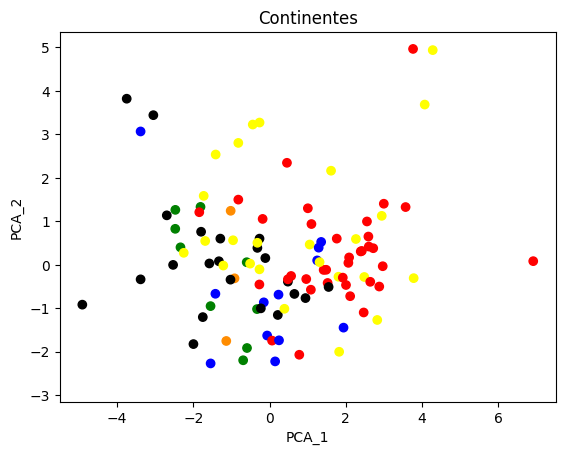

In [ ]:
continent_colors = {
    'Europe': 'red',
    'North America': 'blue',
    'South America': 'green',
    'Asia': 'yellow',
    'Africa': 'black',
    'Oceania': 'darkorange'}
#No graficamos puntos que no tenan definidos los continentes
colors_2 = [continent_colors.get(continent, "#FF000000") for continent in data_scl_c['Continent']]

#Utilizamos PCA defindio en pregunta 2.11
plt.scatter(dfscl_pca[:, 0], dfscl_pca[:, 1],c=colors_2)
plt.title('Continentes')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
plt.show()

Los gráficos de PCA y los pesos de las variables revelan las principales diferencias entre los continentes. El PC1 refleja la sofisticación económica y la exportación de manufacturas y alta tecnología. Las variables como Manufactures exports (0.46) y Computer; communications (0.41) son clave aquí. Los países de Europa y Norteamérica tienden a puntuar alto en PC1, indicando economías avanzadas.

El PC2 discrimina por la dependencia de recursos primarios y servicios tradicionales. Variables como Transport services (0.42), Insurance and financial services (0.39), y Fuel exports (0.39) definen esta dimensión. Sudamérica y África se inclinan hacia valores más bajos en PC1 (menor sofisticación) y una mayor influencia de PC2 (recursos primarios). Asia muestra una dispersión, abarcando desde economías sofisticadas hasta otras más dependientes de recursos.

### Pregunta 2.14

Genera el mismo gráfico anterior, pero ahora coloree los puntos del scatterplot usando los clusters de un KMeans de 3 clústers y `random_state=42`. Describa los clusters según el gráfico.



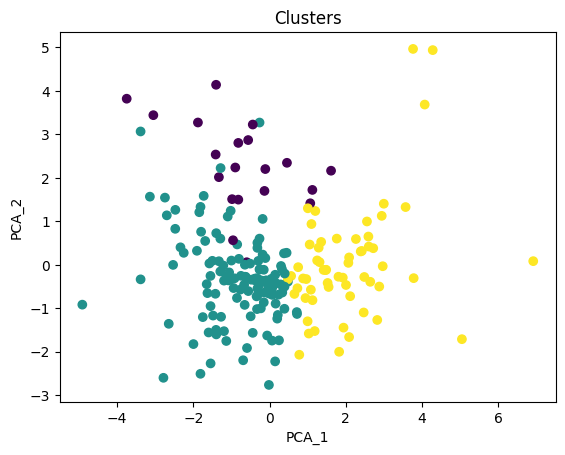

In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42,n_init=10)
clusters = kmeans.fit_predict(data_scl)

plt.scatter(dfscl_pca[:, 0], dfscl_pca[:, 1],c=clusters)
plt.title('Clusters')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
plt.show()

El clúster amarillo se extiende a lo largo del eje PC1 positivo, indicando una fuerte relación con exportaciones de alta tecnología, manufacturas, servicios de computación/comunicaciones y ICT.

El clúster verde se concentra en PC1 negativo, sugiriendo una menor dependencia de las variables de PC1. Se extiende en el eje PC2, implicando una posible relación con servicios de transporte, seguros/financieros y exportaciones de bienes y servicios.

El clúster morado, disperso, parece representar un equilibrio entre ambos ejes, con algunos puntos mostrando alta influencia de las variables de PC1 y otros una mezcla con PC2.

### Pregunta 2.15

¿Cual es la proporcion de cada cluster por continente?


In [ ]:
cross_tab = pd.crosstab(data_scl_c['Continent'], clusters, normalize='index')
print(cross_tab)

col_0                 0         1         2
Continent                                  
Africa         0.090909  0.772727  0.136364
Asia           0.200000  0.360000  0.440000
Europe         0.055556  0.111111  0.833333
North America  0.000000  0.666667  0.333333
Oceania        0.000000  1.000000  0.000000
South America  0.111111  0.888889  0.000000


### Pregunta 2.16

¿Cuál es la característica numérica más alta en magnitud por cluster (usando sus centroides)? ¿Cuál es su signo? ¿Como nos ayuda a interpretar los clusters? ¿Que podemos concluir de cada uno de estos clusters en contexto de la guerra comercial?


In [ ]:
# Características más importantes por cluster
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=data_scl.columns)

for cluster in range(3):
    print(f"\nCluster {cluster}:")
    top_features = centroids.iloc[cluster].abs().sort_values(ascending=False).head(3)
    print("Variables más importantes:")
    print(top_features)

    # Interpretación
    print("\nInterpretación:")
    for feature in top_features.index:
        value = centroids.iloc[cluster][feature]
        print(f"- {feature}: {'Alto' if value > 0 else 'Bajo'} valor ({value:.2f})")


Cluster 0:
Variables más importantes:
Series Name
Fuel exports (% of merchandise exports)                 2.606433
Transport services (% of commercial service exports)    1.336154
Manufactures exports (% of merchandise exports)         0.929503
Name: 0, dtype: float64

Interpretación:
- Fuel exports (% of merchandise exports): Alto valor (2.61)
- Transport services (% of commercial service exports): Alto valor (1.34)
- Manufactures exports (% of merchandise exports): Bajo valor (-0.93)

Cluster 1:
Variables más importantes:
Series Name
Manufactures exports (% of merchandise exports)        0.377593
High-technology exports (% of manufactured exports)    0.356908
Food exports (% of merchandise exports)                0.295035
Name: 1, dtype: float64

Interpretación:
- Manufactures exports (% of merchandise exports): Bajo valor (-0.38)
- High-technology exports (% of manufactured exports): Bajo valor (-0.36)
- Food exports (% of merchandise exports): Alto valor (0.30)

Cluster 2:
Variabl

Cluster 0:

* Más alto en magnitud: "Exportaciones de Combustible" (2.61).
* Signo: Positivo.
* Interpretación: Este grupo incluye economías que dependen mucho de exportar combustible y servicios de transporte, con pocas exportaciones de manufacturas. En una guerra comercial, serían vulnerables si el precio del combustible o las rutas de envío se ven afectadas, o si hay aranceles en manufacturas.

Cluster 1:

* Más alto en magnitud: "Exportaciones de Manufacturas" (-0.38).
* Signo: Negativo.
* Interpretación: Este grupo representa economías con bajas exportaciones de manufacturas y alta tecnología, pero que se centran en exportar alimentos. En una guerra comercial, podrían resistir mejor si los alimentos no son blanco de aranceles, pero serían vulnerables si sí lo son o si la demanda baja.

Cluster 2:

* Más alto en magnitud: "Exportaciones de Manufacturas" (1.20).
* Signo: Positivo.
* Interpretación: Este grupo abarca economías con muchas exportaciones de manufacturas, alta tecnología y servicios informáticos/de comunicación. En una guerra comercial, enfrentarían grandes riesgos por su dependencia de las cadenas de suministro globales y posibles aranceles en tecnología, aunque podrían beneficiarse si logran abrir nuevos mercados.